In [1]:
# @title Cell 1 · Mount Drive & Install

from google.colab import drive
drive.mount('/content/drive')

!pip install librosa scikit-learn tensorflow pandas scipy seaborn tqdm tabulate -q
!pip install torch torchaudio -q

import torch
_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device : {_device}")
if _device.type == "cuda":
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU — U-Net training will be slow. Runtime > Change runtime type > GPU")

Mounted at /content/drive
PyTorch device : cuda
GPU            : Tesla T4
VRAM           : 15.6 GB


In [2]:
# @title Cell 2 · Imports + Seed

import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as TAT

from pathlib               import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics       import (classification_report, confusion_matrix,
                                   roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
from scipy.signal          import butter, filtfilt, stft, istft
from scipy.special         import exp1
from scipy.stats           import ttest_rel, t, sem, wilcoxon
from tensorflow.keras      import layers, models, regularizers

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅  Imports done")
print(f"    PyTorch device: {device}")

✅  Imports done
    PyTorch device: cuda


In [3]:
# @title Cell 3 · Paths & traffic file upload

DATA_PATH  = "/content/drive/MyDrive/Trial DSP/ESC-50-master"
AUDIO_PATH = os.path.join(DATA_PATH, "audio")
META_PATH  = os.path.join(DATA_PATH, "meta", "esc50.csv")
SAVE_DIR   = os.path.join(DATA_PATH, "saved_models")
os.makedirs(SAVE_DIR, exist_ok=True)

RESULTS_DIR = Path(DATA_PATH) / "unified_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR     = Path(DATA_PATH) / "unet_denoiser"
OUT_MODELS  = OUT_DIR / "models"
OUT_LOGS    = OUT_DIR / "logs"
for _d in [OUT_MODELS, OUT_LOGS]:
    _d.mkdir(parents=True, exist_ok=True)

meta = pd.read_csv(META_PATH)
print(f"Samples : {len(meta)}")
print(f"Classes : {meta['category'].nunique()}")

from google.colab import files as colab_files
print("\n📂  Upload your traffic noise file (m4a OR wav)…")
uploaded = colab_files.upload()
if len(uploaded) != 1:
    raise ValueError(f"Upload exactly 1 file. Got {len(uploaded)}.")

_fname        = list(uploaded.keys())[0]
_upload_path  = Path("/content") / _fname
_upload_path.write_bytes(uploaded[_fname])

if _upload_path.suffix.lower() == ".m4a":
    print(f"🔄  Detected m4a — converting to WAV…")
    import subprocess
    _wav_path = _upload_path.with_suffix(".wav")
    result = subprocess.run(
        ["ffmpeg", "-y", "-i", str(_upload_path),
         "-ar", "22050", "-ac", "1", str(_wav_path)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"ffmpeg conversion failed:\n{result.stderr}")
    TRAFFIC_PATH = _wav_path
    print(f"✅  Converted → {TRAFFIC_PATH.name}")
else:
    TRAFFIC_PATH = _upload_path
    print(f"✅  Traffic file: {TRAFFIC_PATH.name}")

_y_chk, _ = librosa.load(str(TRAFFIC_PATH), sr=22050, mono=True)
print(f"    Duration : {len(_y_chk)/22050:.2f} s")
print(f"    RMS      : {np.sqrt(np.mean(_y_chk**2)):.5f}")
del _y_chk


Samples : 2000
Classes : 50

📂  Upload your traffic noise file (m4a OR wav)…


Saving 851965_34mwi_crowd_traffic_under_bridge_in_cairo_mp3cut_net.m4a to 851965_34mwi_crowd_traffic_under_bridge_in_cairo_mp3cut_net.m4a
🔄  Detected m4a — converting to WAV…
✅  Converted → 851965_34mwi_crowd_traffic_under_bridge_in_cairo_mp3cut_net.wav
    Duration : 5.05 s
    RMS      : 0.11492


In [4]:
# @title Cell 4 · Settings

SAMPLE_RATE = 22050
DURATION    = 5
MAX_LEN     = SAMPLE_RATE * DURATION
TARGET_RMS  = 0.1
TEST_FOLD   = 5

N_FFT      = 512
HOP_LENGTH = 128
WIN_LENGTH = 512

UNET_EPOCHS         = 25
UNET_LR             = 1e-3
UNET_BATCH_SIZE     = 8
UNET_WEIGHT_DECAY   = 1e-5
EARLY_STOP_PATIENCE = 5
UNET_BASE_CH        = 16

WHITE_SNR_LEVELS    = [20, 15, 10, 5, 0]
GAUSSIAN_SNR_LEVELS = [20, 15, 10, 5, 0]
LOW_SNR_LEVELS      = [0, -5, -10]
TRAFFIC_SNR_LEVELS  = [-10, -5, 0, 5, 10, 15, 20]

N_RUNS = 5
SEEDS  = [SEED + i for i in range(N_RUNS)]

INNER_VAL_FRAC = 0.10
INNER_VAL_SEED = 42

print("✅  Settings done")
print(f"    SR={SAMPLE_RATE} | N_FFT={N_FFT} | HOP={HOP_LENGTH} | WIN={WIN_LENGTH}")
print(f"    U-Net epochs={UNET_EPOCHS} | lr={UNET_LR} | batch={UNET_BATCH_SIZE}")
print(f"    Traffic SNRs  = {TRAFFIC_SNR_LEVELS}")
print(f"    Runs / Seeds  = {N_RUNS} / {SEEDS}")

✅  Settings done
    SR=22050 | N_FFT=512 | HOP=128 | WIN=512
    U-Net epochs=25 | lr=0.001 | batch=8
    Traffic SNRs  = [-10, -5, 0, 5, 10, 15, 20]
    Runs / Seeds  = 5 / [42, 43, 44, 45, 46]


In [5]:
# @title Cell 5 · Label encoding

le = LabelEncoder()
le.fit(meta["category"])
NUM_CLASSES = len(le.classes_)
print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 50


In [6]:
# @title Cell 6 · Audio loading helpers

def rms_normalize(y, target_rms=TARGET_RMS):
    rms = np.sqrt(np.mean(y ** 2))
    if rms < 1e-9:
        return y
    return (y * target_rms / rms).astype(np.float32)

def load_wave(path):
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)))
    else:
        y = y[:MAX_LEN]
    return rms_normalize(y).astype(np.float32)

def build_dataset(df):
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(AUDIO_PATH, row["filename"])
        X.append(load_wave(path))
        y.append(row["category"])
    X = np.array(X, dtype=np.float32)[..., np.newaxis]
    y = np.array(le.transform(y), dtype=np.int32)
    return X, y

print("✅  rms_normalize / load_wave / build_dataset defined")

✅  rms_normalize / load_wave / build_dataset defined


In [7]:
# @title Cell 7 · Load saved model + test set

from tensorflow.keras.models import load_model

MODEL_PATH = os.path.join(SAVE_DIR, "final_model_v2.keras")

print(f"Loading model from {MODEL_PATH} …")
final_model = load_model(MODEL_PATH)
print(f"✅  Model loaded  |  parameters: {final_model.count_params():,}")

print(f"\nLoading test set (fold {TEST_FOLD}) …")
test_meta = meta[meta["fold"] == TEST_FOLD]
X_test, y_test = build_dataset(test_meta)
print(f"✅  Test set: {len(X_test)} samples  |  shape: {X_test.shape}")

raw_waves = X_test[..., 0]
print(f"    raw_waves shape: {raw_waves.shape}")

Loading model from /content/drive/MyDrive/Trial DSP/ESC-50-master/saved_models/final_model_v2.keras …
✅  Model loaded  |  parameters: 203,198

Loading test set (fold 5) …
✅  Test set: 400 samples  |  shape: (400, 110250, 1)
    raw_waves shape: (400, 110250)


In [8]:
# @title Cell 8 · STFT / iSTFT torch helpers

_WINDOW_NP = torch.hann_window(N_FFT, periodic=True)

def stft_torch(wav):
    window = _WINDOW_NP.to(wav.device)
    return torch.stft(
        wav, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        window=window, return_complex=True, center=True,
    )

def istft_torch(stft_c, length):
    window = _WINDOW_NP.to(stft_c.device)
    return torch.istft(
        stft_c, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        window=window, center=True, length=length,
    )

_dummy = torch.zeros(1, MAX_LEN)
_spec  = stft_torch(_dummy)
print(f"✅  STFT helpers ready")
print(f"    Input  : (1, {MAX_LEN})  →  STFT (1, {_spec.shape[1]}, {_spec.shape[2]})")
del _dummy, _spec

✅  STFT helpers ready
    Input  : (1, 110250)  →  STFT (1, 257, 862)


In [9]:
# @title Cell 9 · U-Net spectral mask denoiser architecture

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class DenoiseUNet(nn.Module):
    def __init__(self, base_ch=UNET_BASE_CH):
        super().__init__()
        c = base_ch
        self.enc1 = nn.Sequential(ConvBNReLU(1,   c),   ConvBNReLU(c,   c))
        self.enc2 = nn.Sequential(ConvBNReLU(c,   c*2), ConvBNReLU(c*2, c*2))
        self.enc3 = nn.Sequential(ConvBNReLU(c*2, c*4), ConvBNReLU(c*4, c*4))
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(ConvBNReLU(c*4, c*8), ConvBNReLU(c*8, c*8))

        self.up3  = nn.ConvTranspose2d(c*8, c*4, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(ConvBNReLU(c*8, c*4), ConvBNReLU(c*4, c*4))

        self.up2  = nn.ConvTranspose2d(c*4, c*2, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(ConvBNReLU(c*4, c*2), ConvBNReLU(c*2, c*2))

        self.up1  = nn.ConvTranspose2d(c*2, c,   kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(ConvBNReLU(c*2, c),   ConvBNReLU(c, c))

        self.out_conv = nn.Conv2d(c, 1, kernel_size=1)

    def forward(self, x):
        B, C, Fdim, Tdim = x.shape
        pad_f = (8 - Fdim % 8) % 8
        pad_t = (8 - Tdim % 8) % 8
        x_p = F.pad(x, (0, pad_t, 0, pad_f))

        e1 = self.enc1(x_p)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        mask = torch.sigmoid(self.out_conv(d1))
        return mask[:, :, :Fdim, :Tdim]


_unet_test = DenoiseUNet().to(device)
_F = N_FFT // 2 + 1
_T = MAX_LEN // HOP_LENGTH + 2
with torch.no_grad():
    _out = _unet_test(torch.randn(2, 1, _F, _T).to(device))
print(f"✅  U-Net OK  —  input (2, 1, {_F}, {_T})  →  mask {tuple(_out.shape)}")
print(f"    Parameters: {sum(p.numel() for p in _unet_test.parameters()):,}")
del _unet_test, _out

✅  U-Net OK  —  input (2, 1, 257, 863)  →  mask (2, 1, 257, 863)
    Parameters: 482,449


In [10]:
# @title Cell 10 · Traffic noise helpers + pre-load audio

def mix_traffic_noise(signal, traffic, snr_db):
    p_signal = np.mean(signal ** 2)
    p_noise  = np.mean(traffic ** 2) + 1e-12
    scale    = np.sqrt((p_signal / (10 ** (snr_db / 10))) / p_noise)
    return np.clip(signal + traffic * scale, -1.0, 1.0).astype(np.float32)

def load_traffic_segment_cached(traffic_audio, n_samples, seed):
    y = traffic_audio
    if len(y) < n_samples:
        y = np.tile(y, int(np.ceil(n_samples / len(y))))
    rng   = np.random.default_rng(seed)
    start = rng.integers(0, len(y) - n_samples + 1)
    seg   = y[start: start + n_samples].astype(np.float32)
    rms   = np.sqrt(np.mean(seg ** 2))
    return (seg / (rms + 1e-9)).astype(np.float32)

def add_traffic_noise_batch(X, snr_db, seed):
    clip_seeds  = [seed * 100_000 + i for i in range(len(X))]
    noisy_clips = [
        mix_traffic_noise(
            X[i].squeeze(),
            load_traffic_segment_cached(TRAFFIC_AUDIO, MAX_LEN, cs),
            snr_db,
        )
        for i, cs in enumerate(clip_seeds)
    ]
    return np.stack(noisy_clips, axis=0)[..., np.newaxis]

def measure_snr_batch(X_clean, X_processed):
    snrs = []
    for c, p in zip(X_clean, X_processed):
        clean       = c.squeeze()
        processed   = p.squeeze()
        noise_power = np.mean((processed - clean) ** 2)
        sig_power   = np.mean(clean ** 2)
        snrs.append(float('inf') if noise_power < 1e-12
                    else 10 * np.log10(sig_power / noise_power))
    return snrs

def ci95(arr):
    if len(arr) < 2:
        return 0.0
    return float(sem(arr) * t.ppf(0.975, df=len(arr) - 1))

print("🔄  Pre-loading traffic audio into memory …")
TRAFFIC_AUDIO, _ = librosa.load(str(TRAFFIC_PATH), sr=SAMPLE_RATE, mono=True)
print(f"✅  Traffic audio loaded  |  {len(TRAFFIC_AUDIO)/SAMPLE_RATE:.1f} s")

🔄  Pre-loading traffic audio into memory …
✅  Traffic audio loaded  |  5.1 s


In [11]:
# @title Cell 11 · Synthetic noise helpers

def add_white_noise(X, target_snr_db, seed=None):
    rng = np.random.default_rng(seed)
    out = []
    for x in X:
        sig         = x.squeeze()
        noise       = rng.uniform(-1, 1, size=len(sig))
        noise_power = np.mean(sig**2) / (10 ** (target_snr_db / 10))
        noise       = noise * np.sqrt(noise_power / (np.mean(noise**2) + 1e-10))
        out.append(np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[..., np.newaxis])
    return np.array(out, dtype=np.float32)

def add_gaussian_noise(X, target_snr_db, seed=None):
    rng = np.random.default_rng(seed)
    out = []
    for x in X:
        sig         = x.squeeze()
        noise       = rng.standard_normal(len(sig))
        noise_power = np.mean(sig**2) / (10 ** (target_snr_db / 10))
        noise       = noise * np.sqrt(noise_power / (np.mean(noise**2) + 1e-10))
        out.append(np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[..., np.newaxis])
    return np.array(out, dtype=np.float32)

def add_low_snr(X, target_snr_db, seed=None):
    return add_gaussian_noise(X, target_snr_db, seed=seed)

print("✅  Synthetic noise helpers defined (white / gaussian / low-snr)")

✅  Synthetic noise helpers defined (white / gaussian / low-snr)


In [12]:
# @title Cell 12 · U-Net training dataset

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

_df_dev = meta[meta["fold"] != TEST_FOLD].reset_index(drop=True)
_df_train_inner, _df_val_inner = train_test_split(
    _df_dev, test_size=INNER_VAL_FRAC, random_state=INNER_VAL_SEED,
    stratify=_df_dev["category"],
)
_df_train_inner = _df_train_inner.reset_index(drop=True)
_df_val_inner   = _df_val_inner.reset_index(drop=True)

print(f"U-Net train : {len(_df_train_inner)} clips (folds 1-4, 90%)")
print(f"U-Net val   : {len(_df_val_inner)} clips  (folds 1-4, 10%)")
print(f"1D CNN test : {len(test_meta)} clips  (fold {TEST_FOLD}, sealed)")

_ALL_SNR_POOL = [-10, -5, 0, 5, 10, 15, 20]


class DenoiseDataset(Dataset):
    def __init__(self, df, seed=None):
        self.df  = df.reset_index(drop=True)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path     = os.path.join(AUDIO_PATH, self.df.iloc[idx]["filename"])
        clean_np = load_wave(path)

        snr        = float(self.rng.choice(_ALL_SNR_POOL))
        noise_type = self.rng.integers(0, 4)

        clean_2d = clean_np[np.newaxis, :]

        if noise_type == 0:
            noisy_2d = add_white_noise([clean_2d], snr, seed=int(self.rng.integers(0, 1_000_000)))[0]
        elif noise_type == 1:
            noisy_2d = add_gaussian_noise([clean_2d], snr, seed=int(self.rng.integers(0, 1_000_000)))[0]
        elif noise_type == 2:
            noisy_2d = add_low_snr([clean_2d], snr, seed=int(self.rng.integers(0, 1_000_000)))[0]
        else:
            traffic_seg = load_traffic_segment_cached(
                TRAFFIC_AUDIO, MAX_LEN, int(self.rng.integers(0, 1_000_000))
            )
            noisy_2d = mix_traffic_noise(clean_np, traffic_seg, snr)[np.newaxis, :]

        clean_wav = torch.tensor(clean_np,           dtype=torch.float32)
        noisy_wav = torch.tensor(noisy_2d.squeeze(), dtype=torch.float32)
        return noisy_wav, clean_wav


_train_ds = DenoiseDataset(_df_train_inner, seed=SEED)
_val_ds   = DenoiseDataset(_df_val_inner,   seed=SEED + 1)

_train_loader = DataLoader(_train_ds, batch_size=UNET_BATCH_SIZE, shuffle=True,
                            num_workers=2, pin_memory=True)
_val_loader   = DataLoader(_val_ds,   batch_size=UNET_BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)

print(f"✅  DataLoaders ready  |  train batches: {len(_train_loader)}  "
      f"val batches: {len(_val_loader)}")

U-Net train : 1440 clips (folds 1-4, 90%)
U-Net val   : 160 clips  (folds 1-4, 10%)
1D CNN test : 400 clips  (fold 5, sealed)
✅  DataLoaders ready  |  train batches: 180  val batches: 20


In [13]:
# @title Cell 13 · U-Net training loop

EPS = 1e-8

_MEL_LOSS = TAT.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH, f_min=50, f_max=8000,
    n_mels=64, power=2.0,
).to(device)
_AMP2DB_LOSS = TAT.AmplitudeToDB(stype="power", top_db=80.0).to(device)

def wav_to_logmel_torch(wav):
    return _AMP2DB_LOSS(_MEL_LOSS(wav))


def _mag_phase(wav):
    spec  = stft_torch(wav)
    mag   = torch.abs(spec)
    phase = spec / (mag + EPS)
    return mag, phase


def denoise_wav_batch_torch(unet_model, noisy_wav):
    mag, phase = _mag_phase(noisy_wav)
    x_in  = torch.log1p(mag).unsqueeze(1)
    mask  = unet_model(x_in).squeeze(1)
    d_spec = (mask * mag) * phase
    return istft_torch(d_spec, length=noisy_wav.shape[-1])


def _run_epoch(unet_model, loader, optimizer=None):
    is_train = optimizer is not None
    unet_model.train() if is_train else unet_model.eval()
    total, n = 0.0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for noisy_wav, clean_wav in loader:
            noisy_wav = noisy_wav.to(device)
            clean_wav = clean_wav.to(device)

            denoised   = denoise_wav_batch_torch(unet_model, noisy_wav)
            mel_den    = wav_to_logmel_torch(denoised)
            mel_clean  = wav_to_logmel_torch(clean_wav)
            loss       = F.l1_loss(mel_den, mel_clean)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
                optimizer.step()

            total += loss.item()
            n     += 1

    return total / max(n, 1)


unet = DenoiseUNet().to(device)
_optimizer  = torch.optim.AdamW(unet.parameters(), lr=UNET_LR,
                                weight_decay=UNET_WEIGHT_DECAY)
_scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(_optimizer, T_max=UNET_EPOCHS)

best_val_loss  = float("inf")
best_unet_path = OUT_MODELS / "unet_best.pth"
_patience_ctr  = 0

print(f"Starting U-Net training for up to {UNET_EPOCHS} epochs "
      f"(early stop patience={EARLY_STOP_PATIENCE}) …\n")

for epoch in range(1, UNET_EPOCHS + 1):
    tr_loss  = _run_epoch(unet, _train_loader, _optimizer)
    val_loss = _run_epoch(unet, _val_loader, optimizer=None)
    _scheduler.step()

    print(f"Epoch {epoch:03d}/{UNET_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  "
          f"lr={_scheduler.get_last_lr()[0]:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        _patience_ctr = 0
        torch.save(unet.state_dict(), best_unet_path)
        print(f"  → saved best checkpoint (val_loss={val_loss:.4f})")
    else:
        _patience_ctr += 1
        if _patience_ctr >= EARLY_STOP_PATIENCE:
            print(f"  Early stop at epoch {epoch} "
                  f"(no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

unet.load_state_dict(torch.load(best_unet_path, map_location=device))
unet.eval()
print(f"\n✅  U-Net trained  |  best val_loss={best_val_loss:.4f}")
print(f"    Checkpoint: {best_unet_path}")

Starting U-Net training for up to 25 epochs (early stop patience=5) …

Epoch 001/25  train_loss=11.3193  val_loss=9.6344  lr=9.96e-04
  → saved best checkpoint (val_loss=9.6344)
Epoch 002/25  train_loss=9.4364  val_loss=8.9738  lr=9.84e-04
  → saved best checkpoint (val_loss=8.9738)
Epoch 003/25  train_loss=8.6332  val_loss=8.5333  lr=9.65e-04
  → saved best checkpoint (val_loss=8.5333)
Epoch 004/25  train_loss=8.3365  val_loss=8.2934  lr=9.38e-04
  → saved best checkpoint (val_loss=8.2934)
Epoch 005/25  train_loss=8.2885  val_loss=7.8802  lr=9.05e-04
  → saved best checkpoint (val_loss=7.8802)
Epoch 006/25  train_loss=7.9989  val_loss=7.7377  lr=8.64e-04
  → saved best checkpoint (val_loss=7.7377)
Epoch 007/25  train_loss=7.5889  val_loss=7.8468  lr=8.19e-04
Epoch 008/25  train_loss=7.9028  val_loss=7.6518  lr=7.68e-04
  → saved best checkpoint (val_loss=7.6518)
Epoch 009/25  train_loss=7.6626  val_loss=7.9258  lr=7.13e-04
Epoch 010/25  train_loss=7.3340  val_loss=10.1415  lr=6.55e-04

In [14]:
# @title Cell 14 · U-Net inference helper

@torch.no_grad()
def dsp_pipeline(X):
    out     = []
    batch_s = UNET_BATCH_SIZE * 4
    for start in range(0, len(X), batch_s):
        batch_np   = X[start:start + batch_s, :, 0]
        batch_t    = torch.tensor(batch_np, dtype=torch.float32, device=device)
        denoised_t = denoise_wav_batch_torch(unet, batch_t)
        denoised_np = denoised_t.cpu().numpy()
        for d in denoised_np:
            out.append(rms_normalize(d)[..., np.newaxis])
    return np.array(out, dtype=np.float32)


_smoke = dsp_pipeline(X_test[:2])
print(f"✅  dsp_pipeline (U-Net) ready")
print(f"    Input  shape: {X_test[:2].shape}")
print(f"    Output shape: {_smoke.shape}")
del _smoke

✅  dsp_pipeline (U-Net) ready
    Input  shape: (2, 110250, 1)
    Output shape: (2, 110250, 1)



───────────────────────────────────────────────────────
  Clean   accuracy = 0.4750  (47.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.17      0.12      0.14         8
       breathing       0.29      0.25      0.27         8
  brushing_teeth       0.58      0.88      0.70         8
     can_opening       0.83      0.62      0.71         8
        car_horn       0.70      0.88      0.78         8
             cat       0.50      0.50      0.50         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.55      0.75      0.63         8
    church_bells       0.54      0.88      0.67         8
        clapping       0.60      0.38      0.46         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       0.83      0.62      0.71         8
             cow       0.67      0.2

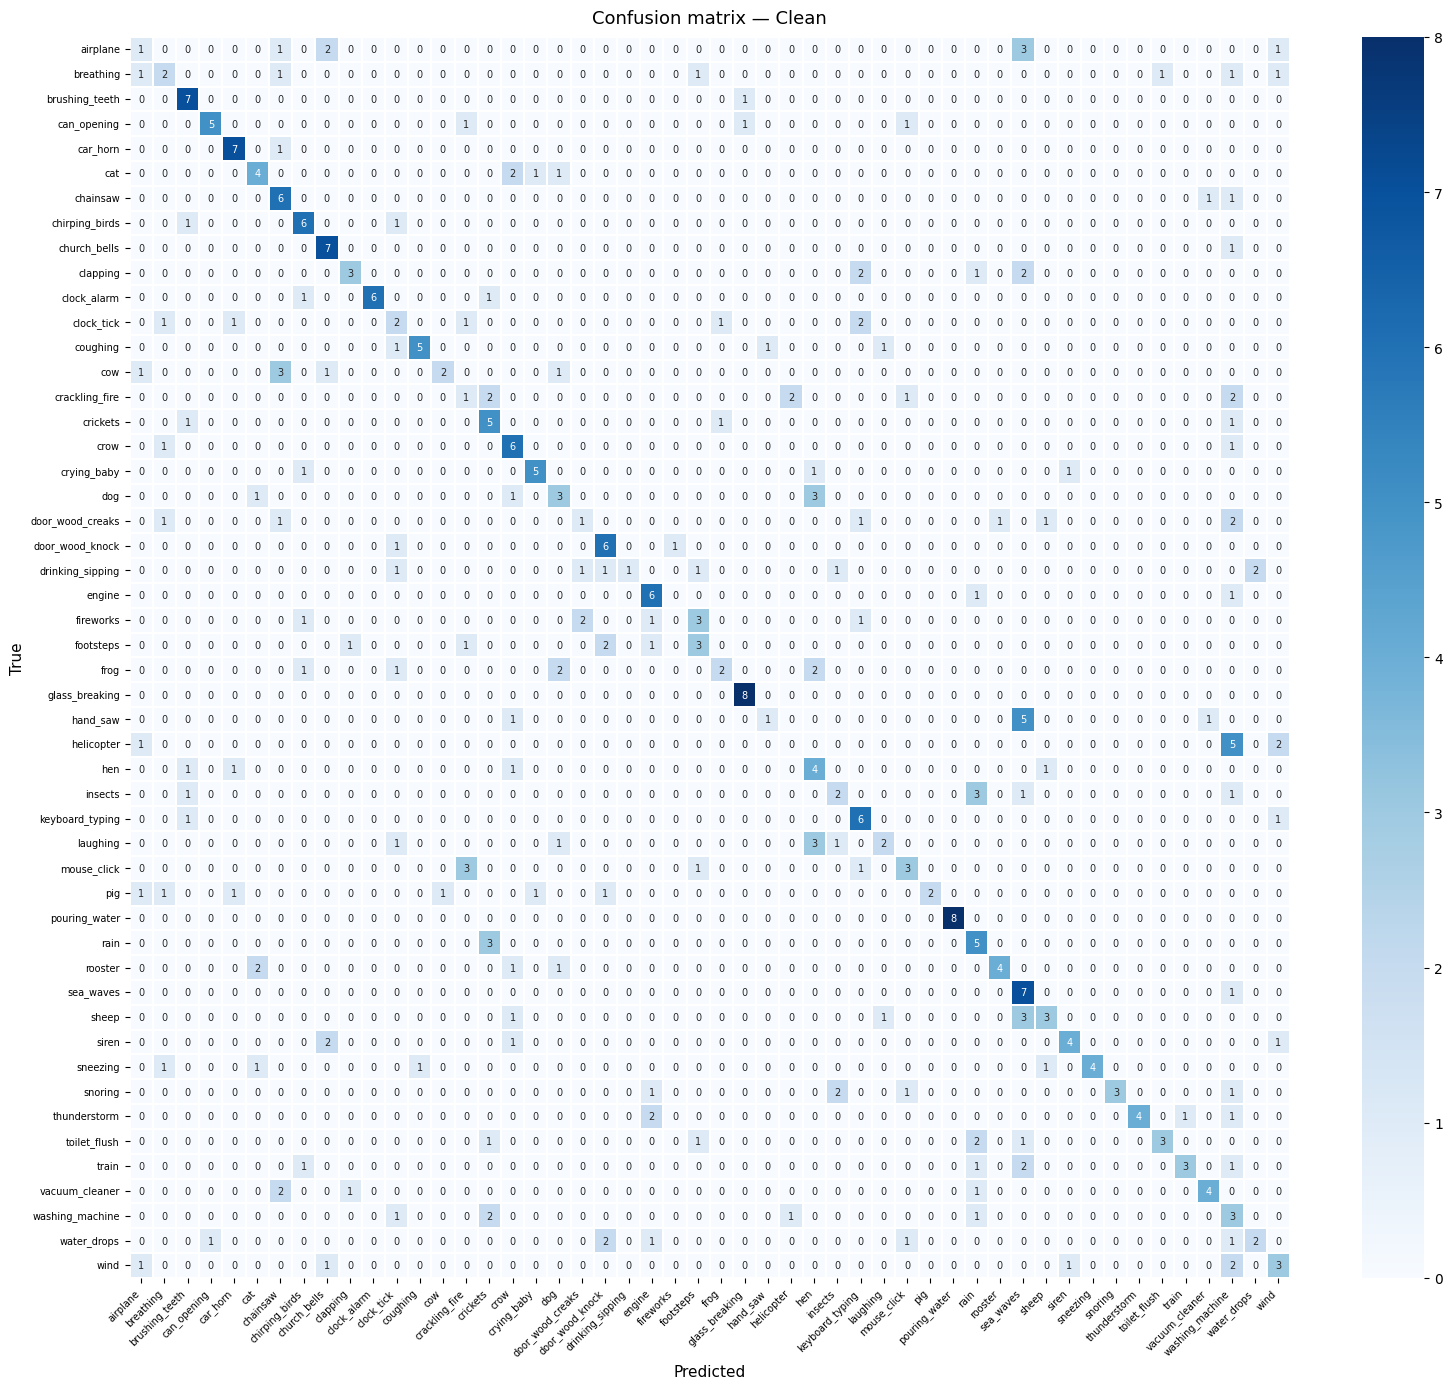


✅  Clean baseline accuracy: 47.50%


In [15]:
# @title Cell 15 · evaluate() helper + clean baseline

def evaluate(model, X, y_int, tag):
    pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = float(np.mean(pred == y_int))
    print(f"\n{'─'*55}")
    print(f"  {tag}   accuracy = {acc:.4f}  ({acc*100:.1f} %)")
    print(f"{'─'*55}")
    print(classification_report(y_int, pred, target_names=le.classes_, zero_division=0))
    cm = confusion_matrix(y_int, pred)
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.3, annot_kws={"size": 7})
    ax.set_title(f"Confusion matrix — {tag}", fontsize=13, pad=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"cm_{tag.replace(' ', '_')}.png"), dpi=150)
    plt.show()
    return acc

acc_clean    = evaluate(final_model, X_test, y_test, "Clean")
baseline_acc = acc_clean
print(f"\n✅  Clean baseline accuracy: {baseline_acc*100:.2f}%")

In [16]:
# @title Cell 16 · All noise robustness — U-Net (White / Gaussian / LowSNR / Traffic, 5 runs each)

results = {
    "white"    : {}, "white_dsp"    : {},
    "gaussian" : {}, "gaussian_dsp" : {},
    "low_snr"  : {}, "low_snr_dsp"  : {},
    "traffic"  : {}, "traffic_dsp"  : {},
    "snr_noisy": {}, "snr_dsp"      : {},
    "snr_gain" : {},
    "clean"    : acc_clean,
    "_runs_noisy"    : {("white",   snr): [] for snr in WHITE_SNR_LEVELS}    |
                       {("gaussian",snr): [] for snr in GAUSSIAN_SNR_LEVELS} |
                       {("low_snr", snr): [] for snr in LOW_SNR_LEVELS}      |
                       {("traffic", snr): [] for snr in TRAFFIC_SNR_LEVELS},
    "_runs_denoised" : {("white",   snr): [] for snr in WHITE_SNR_LEVELS}    |
                       {("gaussian",snr): [] for snr in GAUSSIAN_SNR_LEVELS} |
                       {("low_snr", snr): [] for snr in LOW_SNR_LEVELS}      |
                       {("traffic", snr): [] for snr in TRAFFIC_SNR_LEVELS},
    "_traffic_runs_noisy"    : {snr: [] for snr in TRAFFIC_SNR_LEVELS},
    "_traffic_runs_denoised" : {snr: [] for snr in TRAFFIC_SNR_LEVELS},
}

def _run_model(X):
    return float(np.mean(np.argmax(final_model.predict(X, verbose=0), axis=1) == y_test))

print(f"WHITE NOISE (U-Net, {N_RUNS} runs each):")
for snr in WHITE_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_white_noise(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results["_runs_noisy"]   [("white", snr)].append(run_n[-1])
        results["_runs_denoised"][("white", snr)].append(run_d[-1])
    results["white"][snr]     = float(np.mean(run_n))
    results["white_dsp"][snr] = float(np.mean(run_d))
    X_n0 = add_white_noise(X_test, snr, seed=SEEDS[0])
    X_d0 = dsp_pipeline(X_n0)
    results["snr_noisy"][("white", snr)] = np.mean(measure_snr_batch(X_test, X_n0))
    results["snr_dsp"]  [("white", snr)] = np.mean(measure_snr_batch(X_test, X_d0))
    results["snr_gain"] [("white", snr)] = (results["snr_dsp"][("white", snr)] -
                                            results["snr_noisy"][("white", snr)])
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → U-Net: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

print(f"\nGAUSSIAN NOISE (U-Net, {N_RUNS} runs each):")
for snr in GAUSSIAN_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_gaussian_noise(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results["_runs_noisy"]   [("gaussian", snr)].append(run_n[-1])
        results["_runs_denoised"][("gaussian", snr)].append(run_d[-1])
    results["gaussian"][snr]     = float(np.mean(run_n))
    results["gaussian_dsp"][snr] = float(np.mean(run_d))
    X_n0 = add_gaussian_noise(X_test, snr, seed=SEEDS[0])
    X_d0 = dsp_pipeline(X_n0)
    results["snr_noisy"][("gaussian", snr)] = np.mean(measure_snr_batch(X_test, X_n0))
    results["snr_dsp"]  [("gaussian", snr)] = np.mean(measure_snr_batch(X_test, X_d0))
    results["snr_gain"] [("gaussian", snr)] = (results["snr_dsp"][("gaussian", snr)] -
                                               results["snr_noisy"][("gaussian", snr)])
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → U-Net: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

print(f"\nLOW SNR (U-Net, {N_RUNS} runs each):")
for snr in LOW_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_low_snr(X_test, snr, seed=run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        run_n.append(_run_model(X_noisy))
        run_d.append(_run_model(X_denoised))
        results["_runs_noisy"]   [("low_snr", snr)].append(run_n[-1])
        results["_runs_denoised"][("low_snr", snr)].append(run_d[-1])
    results["low_snr"][snr]     = float(np.mean(run_n))
    results["low_snr_dsp"][snr] = float(np.mean(run_d))
    X_n0 = add_low_snr(X_test, snr, seed=SEEDS[0])
    X_d0 = dsp_pipeline(X_n0)
    results["snr_noisy"][("low_snr", snr)] = np.mean(measure_snr_batch(X_test, X_n0))
    results["snr_dsp"]  [("low_snr", snr)] = np.mean(measure_snr_batch(X_test, X_d0))
    results["snr_gain"] [("low_snr", snr)] = (results["snr_dsp"][("low_snr", snr)] -
                                               results["snr_noisy"][("low_snr", snr)])
    print(f"  {snr:>3}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → U-Net: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%")

print(f"\nTRAFFIC NOISE (U-Net, {N_RUNS} runs each):")
for snr in TRAFFIC_SNR_LEVELS:
    run_n, run_d = [], []
    for run_seed in SEEDS:
        X_noisy    = add_traffic_noise_batch(X_test, snr, run_seed)
        X_denoised = dsp_pipeline(X_noisy)
        acc_n = _run_model(X_noisy)
        acc_d = _run_model(X_denoised)
        run_n.append(acc_n); run_d.append(acc_d)
        results["_runs_noisy"]   [("traffic", snr)].append(acc_n)
        results["_runs_denoised"][("traffic", snr)].append(acc_d)
        results["_traffic_runs_noisy"][snr].append(acc_n)
        results["_traffic_runs_denoised"][snr].append(acc_d)
    results["traffic"][snr]     = float(np.mean(run_n))
    results["traffic_dsp"][snr] = float(np.mean(run_d))
    print(f"  {snr:>4}dB | Noisy: {np.mean(run_n)*100:.1f}%±{np.std(run_n,ddof=1)*100:.1f}%"
          f"  → U-Net: {np.mean(run_d)*100:.1f}%±{np.std(run_d,ddof=1)*100:.1f}%"
          f"  (mean of {N_RUNS} runs)")

print(f"\n✅  All noise scenarios complete ({N_RUNS} runs each)")

WHITE NOISE (U-Net, 5 runs each):
   20dB | Noisy: 37.0%±0.1%  → U-Net: 47.2%±0.2%
   15dB | Noisy: 33.1%±0.1%  → U-Net: 47.2%±0.1%
   10dB | Noisy: 23.0%±0.3%  → U-Net: 46.6%±0.2%
    5dB | Noisy: 16.4%±0.4%  → U-Net: 45.6%±0.5%
    0dB | Noisy: 10.2%±0.2%  → U-Net: 33.3%±0.7%

GAUSSIAN NOISE (U-Net, 5 runs each):
   20dB | Noisy: 37.0%±0.1%  → U-Net: 47.3%±0.2%
   15dB | Noisy: 33.1%±0.3%  → U-Net: 47.0%±0.2%
   10dB | Noisy: 23.2%±0.3%  → U-Net: 46.5%±0.5%
    5dB | Noisy: 16.4%±0.3%  → U-Net: 45.2%±0.5%
    0dB | Noisy: 10.5%±0.5%  → U-Net: 32.4%±1.1%

LOW SNR (U-Net, 5 runs each):
    0dB | Noisy: 10.5%±0.5%  → U-Net: 32.4%±1.1%
   -5dB | Noisy: 6.5%±0.4%  → U-Net: 17.1%±0.7%
  -10dB | Noisy: 2.4%±0.1%  → U-Net: 4.2%±0.1%

TRAFFIC NOISE (U-Net, 5 runs each):
   -10dB | Noisy: 3.4%±0.2%  → U-Net: 25.3%±1.0%  (mean of 5 runs)
    -5dB | Noisy: 2.8%±0.0%  → U-Net: 41.9%±0.1%  (mean of 5 runs)
     0dB | Noisy: 10.2%±0.4%  → U-Net: 46.1%±0.2%  (mean of 5 runs)
     5dB | Noisy: 21.0%±

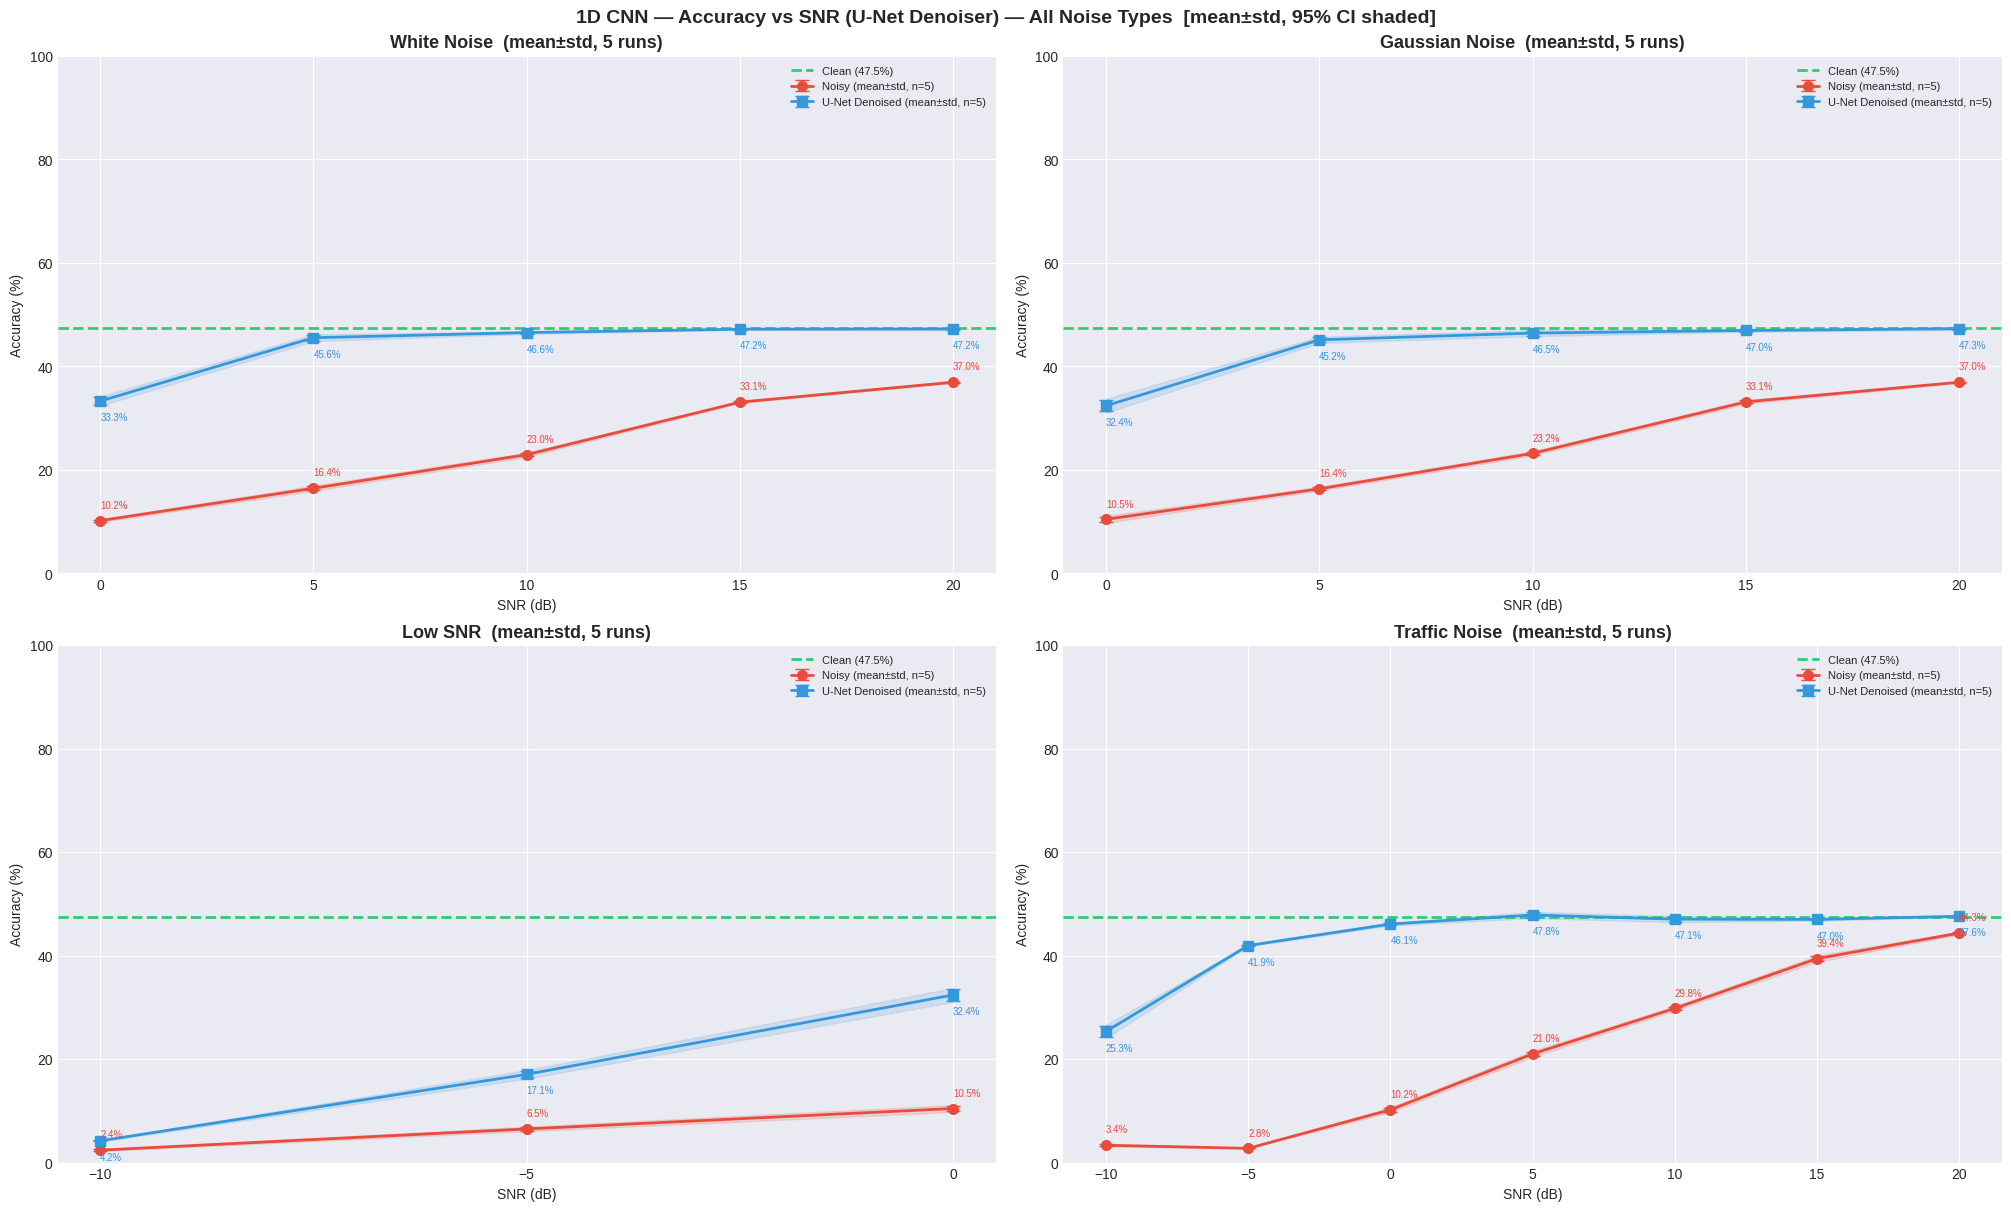

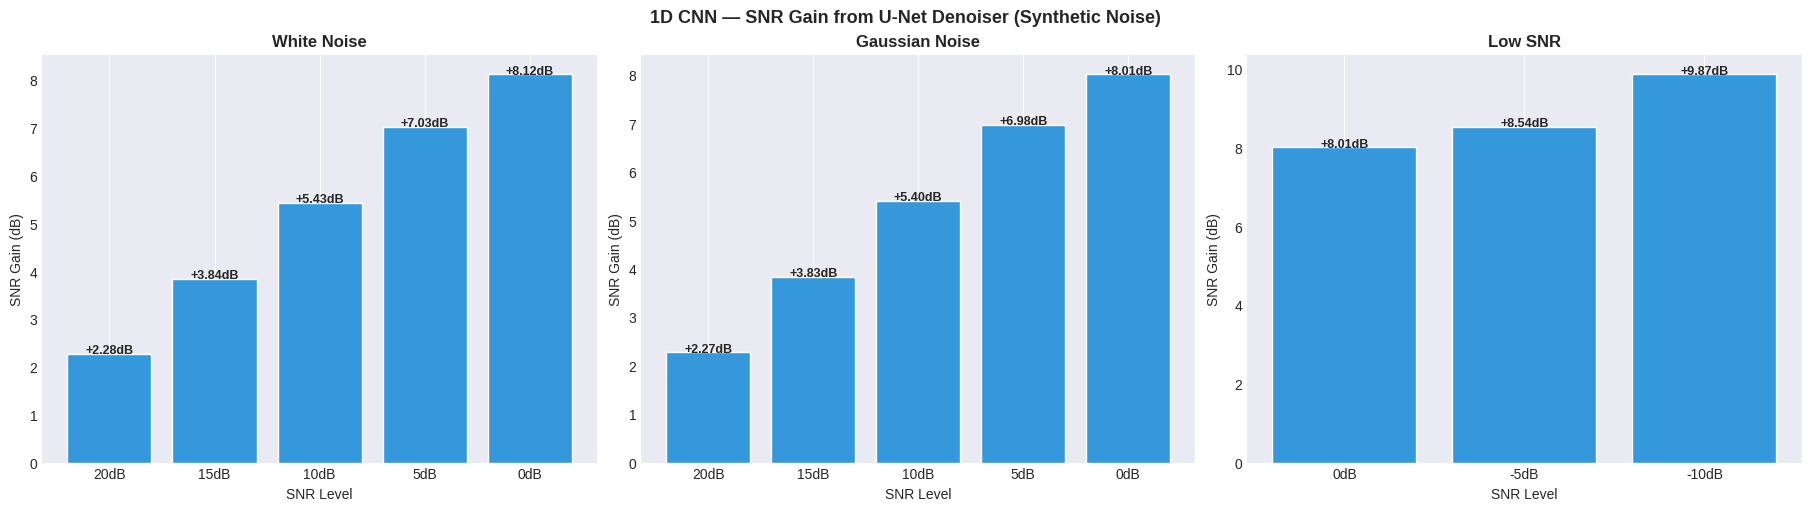

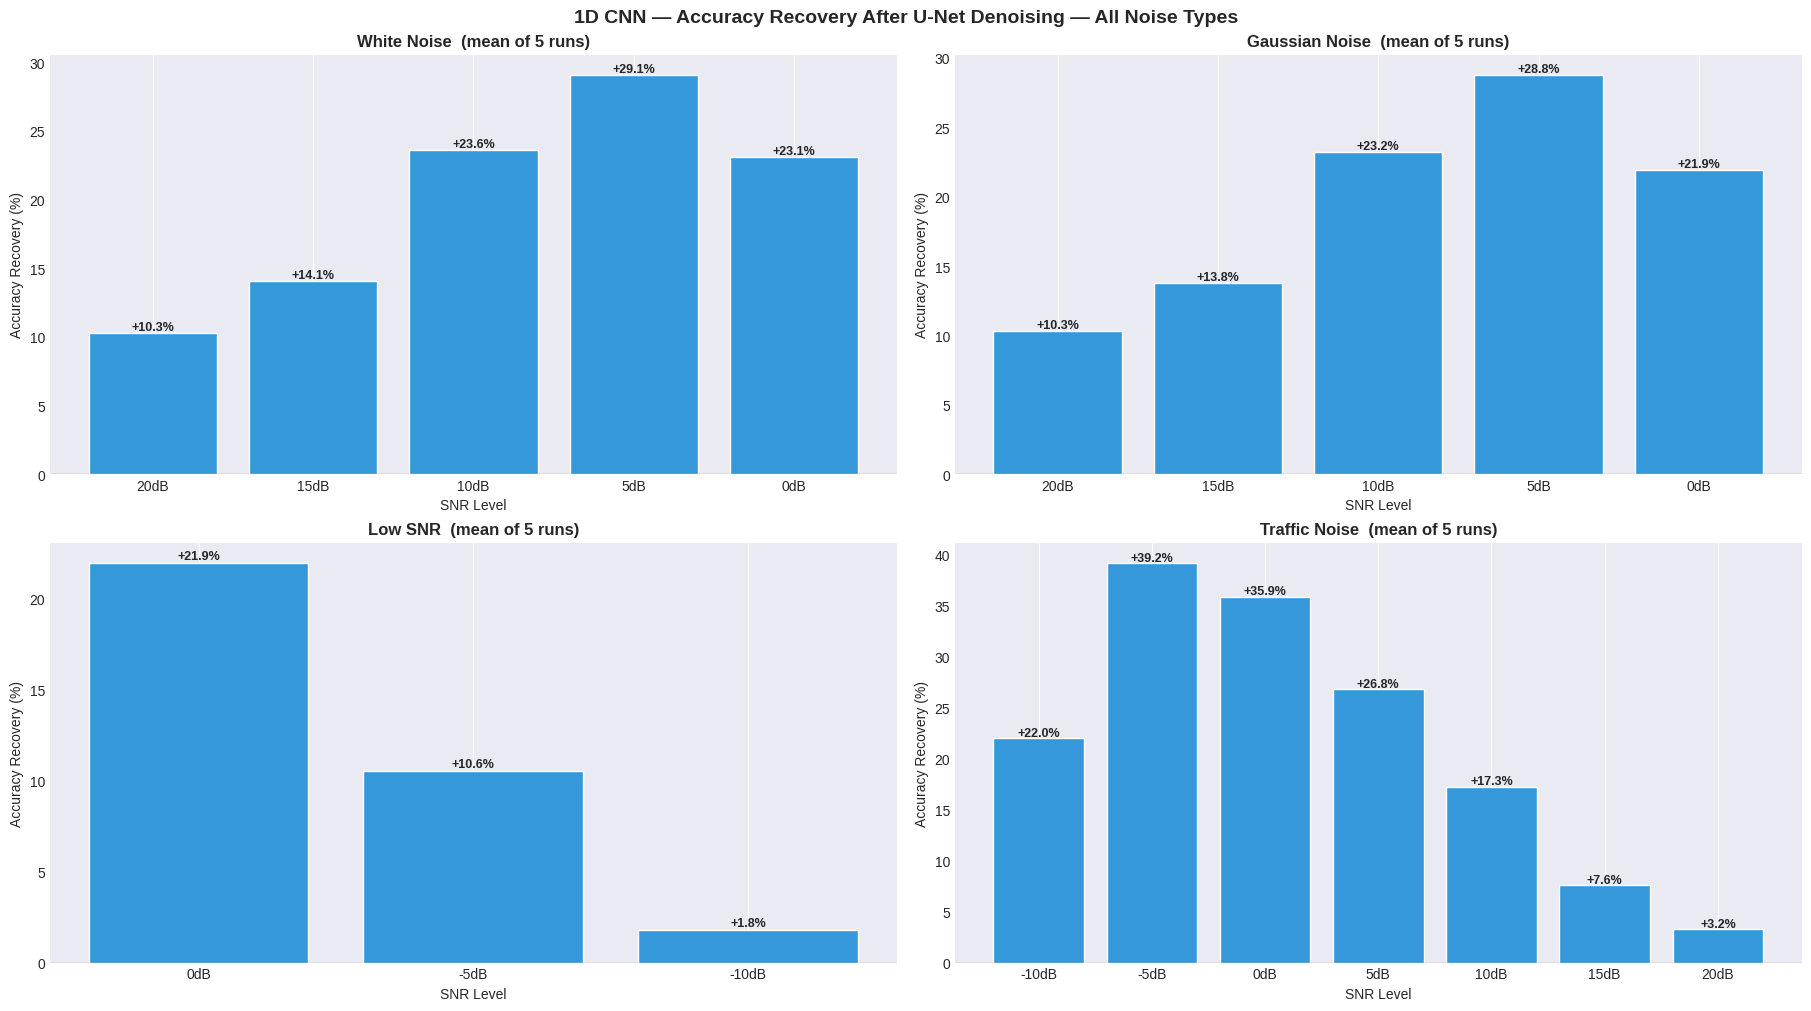

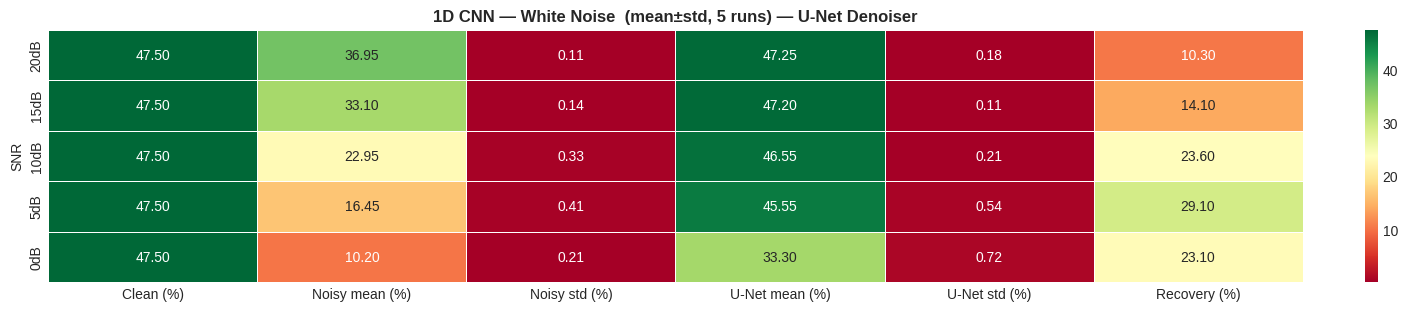

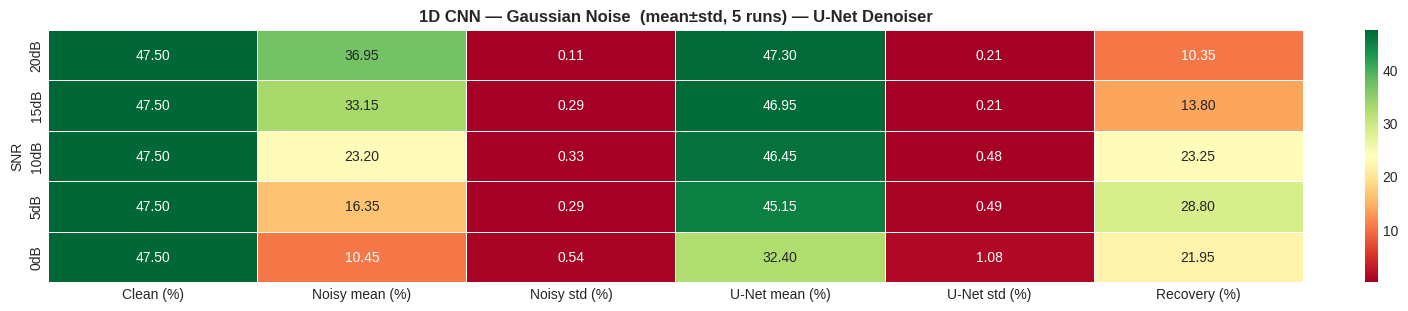

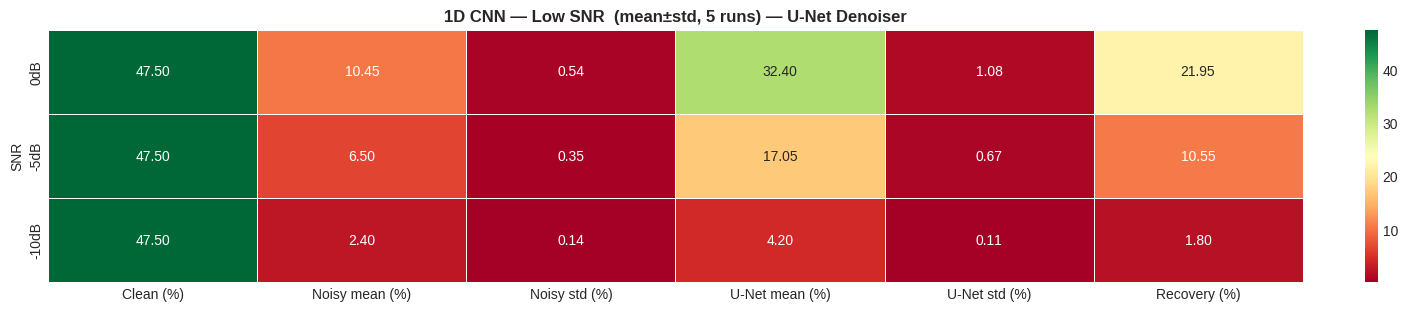

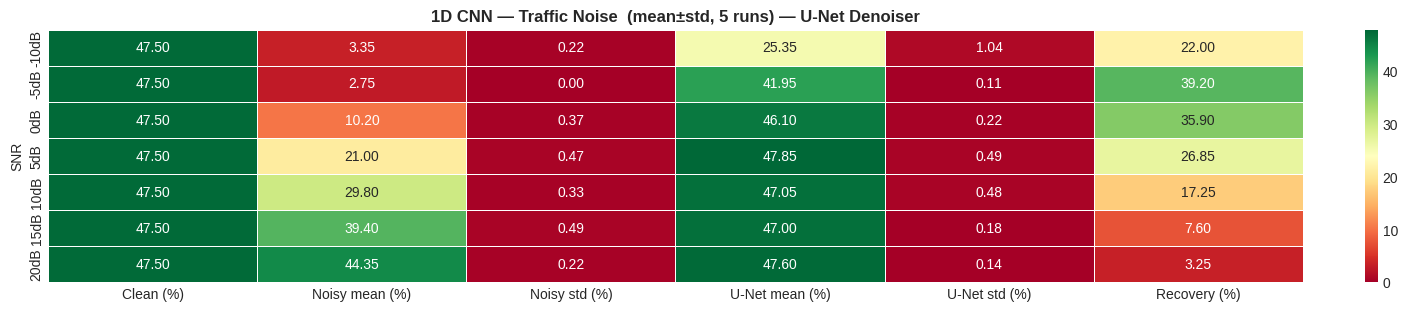

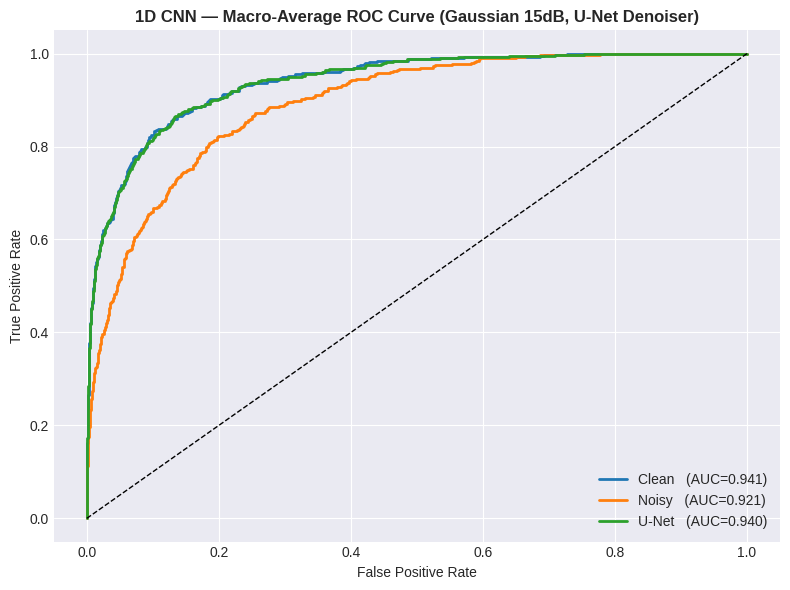


  1D CNN — RESULTS SUMMARY (U-Net Denoiser) — All Noise Types  |  5 runs each
  Clean Baseline: 47.50%

  Noise             SNR   Noisy mean    ±std  U-Net mean    ±std    Recovery    CI95±    p-value    Sig
  ────────────────────────────────────────────────────────────────────────────────────────
  White Noise        20dB      36.95%   0.11%     47.25%   0.18%     +10.30%    0.22%    0.0625(W)       
  White Noise        15dB      33.10%   0.14%     47.20%   0.11%     +14.10%    0.14%    0.0625(W)       
  White Noise        10dB      22.95%   0.33%     46.55%   0.21%     +23.60%    0.26%    0.0625(W)       
  White Noise         5dB      16.45%   0.41%     45.55%   0.54%     +29.10%    0.67%    0.0625(W)       
  White Noise         0dB      10.20%   0.21%     33.30%   0.72%     +23.10%    0.89%    0.0625(W)       

  Gaussian Noise     20dB      36.95%   0.11%     47.30%   0.21%     +10.35%    0.26%    0.0625(W)       
  Gaussian Noise     15dB      33.15%   0.29%     46.95%   0.21

In [17]:
# @title Cell 17 · Unified plots & summary — U-Net (all 4 noise types)

C_PLOT = {"clean": "#2ecc71", "noisy": "#e74c3c", "dsp": "#3498db"}
plt.style.use("seaborn-v0_8-darkgrid")

NOISE_CONFIGS = {
    "White Noise":    ("white",    "white_dsp",    WHITE_SNR_LEVELS),
    "Gaussian Noise": ("gaussian", "gaussian_dsp", GAUSSIAN_SNR_LEVELS),
    "Low SNR":        ("low_snr",  "low_snr_dsp",  LOW_SNR_LEVELS),
    "Traffic Noise":  ("traffic",  "traffic_dsp",  TRAFFIC_SNR_LEVELS),
}

def _get_run_arrays(ntype_key, snr_list):
    n_means, n_stds, n_cis = [], [], []
    d_means, d_stds, d_cis = [], [], []
    for s in snr_list:
        na = np.array(results["_runs_noisy"]   [(ntype_key, s)])
        da = np.array(results["_runs_denoised"][(ntype_key, s)])
        n_means.append(np.mean(na)*100); n_stds.append(np.std(na,ddof=1)*100); n_cis.append(ci95(na)*100)
        d_means.append(np.mean(da)*100); d_stds.append(np.std(da,ddof=1)*100); d_cis.append(ci95(da)*100)
    return n_means, n_stds, n_cis, d_means, d_stds, d_cis

# GRAPH 1: Accuracy vs SNR — 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(20, 12), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(axes.flatten(), NOISE_CONFIGS.items()):
    nm, ns, nc, dm, ds, dc = _get_run_arrays(nkey, snr_list)
    ax.axhline(results["clean"]*100, color=C_PLOT["clean"], lw=2, ls="--",
               label=f"Clean ({results['clean']*100:.1f}%)")
    ax.fill_between(snr_list, np.array(nm)-np.array(nc), np.array(nm)+np.array(nc),
                    alpha=0.15, color=C_PLOT["noisy"])
    ax.fill_between(snr_list, np.array(dm)-np.array(dc), np.array(dm)+np.array(dc),
                    alpha=0.15, color=C_PLOT["dsp"])
    ax.errorbar(snr_list, nm, yerr=ns, fmt="o-", color=C_PLOT["noisy"],
                capsize=5, lw=2, ms=7, label=f"Noisy (mean±std, n={N_RUNS})")
    ax.errorbar(snr_list, dm, yerr=ds, fmt="s-", color=C_PLOT["dsp"],
                capsize=5, lw=2, ms=7, label=f"U-Net Denoised (mean±std, n={N_RUNS})")
    for s, n, d in zip(snr_list, nm, dm):
        ax.annotate(f"{n:.1f}%", (s, n), textcoords="offset points",
                    xytext=(0, 9),  fontsize=7, color=C_PLOT["noisy"])
        ax.annotate(f"{d:.1f}%", (s, d), textcoords="offset points",
                    xytext=(0,-14), fontsize=7, color=C_PLOT["dsp"])
    ax.set_title(f"{noise_label}  (mean±std, {N_RUNS} runs)", fontsize=13, fontweight="bold")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(snr_list); ax.set_ylim(0, 100)
    ax.legend(fontsize=8); ax.grid(True)
plt.suptitle("1D CNN — Accuracy vs SNR (U-Net Denoiser) — All Noise Types  [mean±std, 95% CI shaded]",
             fontsize=14, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "unet_accuracy_vs_snr_all.png"), dpi=150)
plt.show()

# GRAPH 2: SNR Gain (synthetic noise only)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(
        axes, {k: v for k, v in NOISE_CONFIGS.items() if k != "Traffic Noise"}.items()):
    gains    = [results["snr_gain"][(nkey, s)] for s in snr_list]
    bar_cols = [C_PLOT["dsp"] if g >= 0 else C_PLOT["noisy"] for g in gains]
    bars     = ax.bar([f"{s}dB" for s in snr_list], gains, color=bar_cols, edgecolor="white")
    for bar, g in zip(bars, gains):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{g:+.2f}dB", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(noise_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("SNR Level"); ax.set_ylabel("SNR Gain (dB)")
    ax.grid(axis="y")
plt.suptitle("1D CNN — SNR Gain from U-Net Denoiser (Synthetic Noise)",
             fontsize=13, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "unet_snr_gain.png"), dpi=150)
plt.show()

# GRAPH 3: Accuracy Recovery — 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(axes.flatten(), NOISE_CONFIGS.items()):
    recovery = [results[dkey][s]*100 - results[nkey][s]*100 for s in snr_list]
    bar_cols = [C_PLOT["dsp"] if v >= 0 else C_PLOT["noisy"] for v in recovery]
    bars     = ax.bar([f"{s}dB" for s in snr_list], recovery,
                      color=bar_cols, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    for bar, v in zip(bars, recovery):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{v:+.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"{noise_label}  (mean of {N_RUNS} runs)", fontsize=12, fontweight="bold")
    ax.set_xlabel("SNR Level"); ax.set_ylabel("Accuracy Recovery (%)")
    ax.grid(axis="y")
plt.suptitle("1D CNN — Accuracy Recovery After U-Net Denoising — All Noise Types",
             fontsize=14, fontweight="bold")
plt.savefig(str(RESULTS_DIR / "unet_accuracy_recovery_all.png"), dpi=150)
plt.show()

# GRAPH 4: Summary heatmaps
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    rows = []
    for s in snr_list:
        na = np.array(results["_runs_noisy"]   [(nkey, s)])
        da = np.array(results["_runs_denoised"][(nkey, s)])
        rows.append({
            "SNR"            : f"{s}dB",
            "Clean (%)"      : round(results["clean"]*100, 2),
            "Noisy mean (%)" : round(np.mean(na)*100, 2),
            "Noisy std (%)"  : round(np.std(na,ddof=1)*100, 2),
            "U-Net mean (%)" : round(np.mean(da)*100, 2),
            "U-Net std (%)"  : round(np.std(da,ddof=1)*100, 2),
            "Recovery (%)"   : round((np.mean(da)-np.mean(na))*100, 2),
        })
    heat_data = pd.DataFrame(rows).set_index("SNR")
    fig, ax = plt.subplots(figsize=(14, 3), constrained_layout=True)
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="RdYlGn",
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(f"1D CNN — {noise_label}  (mean±std, {N_RUNS} runs) — U-Net Denoiser",
                 fontsize=12, fontweight="bold")
    plt.savefig(str(RESULTS_DIR / f"unet_heatmap_{nkey}.png"), dpi=150)
    plt.show()

# GRAPH 5: AUC-ROC on Gaussian 15dB
y_bin       = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
X_g15       = add_gaussian_noise(X_test, 15, seed=SEEDS[0])
X_g15_dsp   = dsp_pipeline(X_g15)
probs_clean = final_model.predict(X_test,    verbose=0)
probs_noisy = final_model.predict(X_g15,     verbose=0)
probs_dsp   = final_model.predict(X_g15_dsp, verbose=0)
auc_clean   = roc_auc_score(y_bin, probs_clean, multi_class="ovr", average="macro")
auc_noisy   = roc_auc_score(y_bin, probs_noisy, multi_class="ovr", average="macro")
auc_dsp     = roc_auc_score(y_bin, probs_dsp,   multi_class="ovr", average="macro")
plt.figure(figsize=(8, 6))
for probs, label, color in [
    (probs_clean, f"Clean   (AUC={auc_clean:.3f})", C_PLOT["clean"]),
    (probs_noisy, f"Noisy   (AUC={auc_noisy:.3f})", C_PLOT["noisy"]),
    (probs_dsp,   f"U-Net   (AUC={auc_dsp:.3f})",   C_PLOT["dsp"]),
]:
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
    plt.plot(fpr, tpr, label=label, linewidth=2)
plt.plot([0,1],[0,1], "k--", linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("1D CNN — Macro-Average ROC Curve (Gaussian 15dB, U-Net Denoiser)", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "unet_roc_gaussian15.png"), dpi=150)
plt.show()

# SUMMARY TABLE
print("\n" + "="*90)
print(f"  1D CNN — RESULTS SUMMARY (U-Net Denoiser) — All Noise Types  |  {N_RUNS} runs each")
print("="*90)
print(f"  Clean Baseline: {results['clean']*100:.2f}%\n")
print(f"  {'Noise':<15} {'SNR':>5}  {'Noisy mean':>11} {'±std':>7}  "
      f"{'U-Net mean':>10} {'±std':>7}  {'Recovery':>10}  {'CI95±':>7}  {'p-value':>9}  {'Sig':>5}")
print("  " + "─"*88)
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    for snr in snr_list:
        na = np.array(results["_runs_noisy"]   [(nkey, snr)])
        da = np.array(results["_runs_denoised"][(nkey, snr)])
        rec = (np.mean(da) - np.mean(na)) * 100
        dci = ci95(da) * 100
        try:
            if not np.allclose(na, da):
                _, pv = wilcoxon(da, na)
                test_name = "W"
            else:
                pv, test_name = float("nan"), "—"
        except Exception:
            _, pv = ttest_rel(da, na) if len(da) >= 2 else (None, float("nan"))
            test_name = "t"
        sig    = "✓" if (not np.isnan(pv) and pv < 0.05) else " "
        pv_str = f"{pv:.4f}({test_name})" if not np.isnan(pv) else "   —   "
        print(f"  {noise_label:<15} {snr:>5}dB  "
              f"{np.mean(na)*100:>9.2f}%  {np.std(na,ddof=1)*100:>5.2f}%  "
              f"{np.mean(da)*100:>8.2f}%  {np.std(da,ddof=1)*100:>5.2f}%  "
              f"{rec:>+9.2f}%  {dci:>6.2f}%  {pv_str:>11}  {sig:>5}")
    print()
print("="*90)
print("  ✓ = p < 0.05 | W = Wilcoxon signed-rank | t = paired t-test")

# Save CSV
csv_rows = []
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    for snr in snr_list:
        na = np.array(results["_runs_noisy"]   [(nkey, snr)])
        da = np.array(results["_runs_denoised"][(nkey, snr)])
        try:
            _, pv = wilcoxon(da, na) if not np.allclose(na, da) else (None, float("nan"))
        except Exception:
            _, pv = ttest_rel(da, na) if len(da) >= 2 else (None, float("nan"))
        csv_rows.append({
            "Noise_Type"      : noise_label,
            "SNR_dB"          : snr,
            "Clean_%"         : round(results["clean"]*100, 2),
            "Noisy_mean_%"    : round(np.mean(na)*100, 2),
            "Noisy_std_%"     : round(np.std(na,ddof=1)*100, 2),
            "Noisy_CI95_%"    : round(ci95(na)*100, 2),
            "UNet_mean_%"     : round(np.mean(da)*100, 2),
            "UNet_std_%"      : round(np.std(da,ddof=1)*100, 2),
            "UNet_CI95_%"     : round(ci95(da)*100, 2),
            "Recovery_%"      : round((np.mean(da)-np.mean(na))*100, 2),
            "p_value"         : round(pv, 6) if not np.isnan(pv) else "—",
            "Significant_p05" : "Yes" if (not np.isnan(pv) and pv < 0.05) else "No",
        })
df_unet_summary = pd.DataFrame(csv_rows)
unet_csv = RESULTS_DIR / "unet_all_noise_statistics.csv"
df_unet_summary.to_csv(str(unet_csv), index=False)
print(f"\n  ✅  Full stats table saved → {unet_csv.name}")


  TRAFFIC NOISE — STATISTICAL DETAIL  |  1D CNN + U-Net Denoiser
  Runs: 5  |  Seeds: [42, 43, 44, 45, 46]  |  SNR levels: [-10, -5, 0, 5, 10, 15, 20] dB
SNR_dB      Condition  Mean_Acc_%  Std_%  CI95_half_% Recovery_% p_value Significant
 Clean Clean Baseline       47.50   0.00         0.00          —       —           —
   -10 Noisy (no DSP)        3.35   0.22         0.28          —     0.0           —
   -10  Noisy + U-Net       25.35   1.04         1.29       22.0     0.0       Yes ✓
    -5 Noisy (no DSP)        2.75   0.00         0.00          —     0.0           —
    -5  Noisy + U-Net       41.95   0.11         0.14       39.2     0.0       Yes ✓
     0 Noisy (no DSP)       10.20   0.37         0.46          —     0.0           —
     0  Noisy + U-Net       46.10   0.22         0.28       35.9     0.0       Yes ✓
     5 Noisy (no DSP)       21.00   0.47         0.58          —     0.0           —
     5  Noisy + U-Net       47.85   0.49         0.61      26.85     0.0       Y

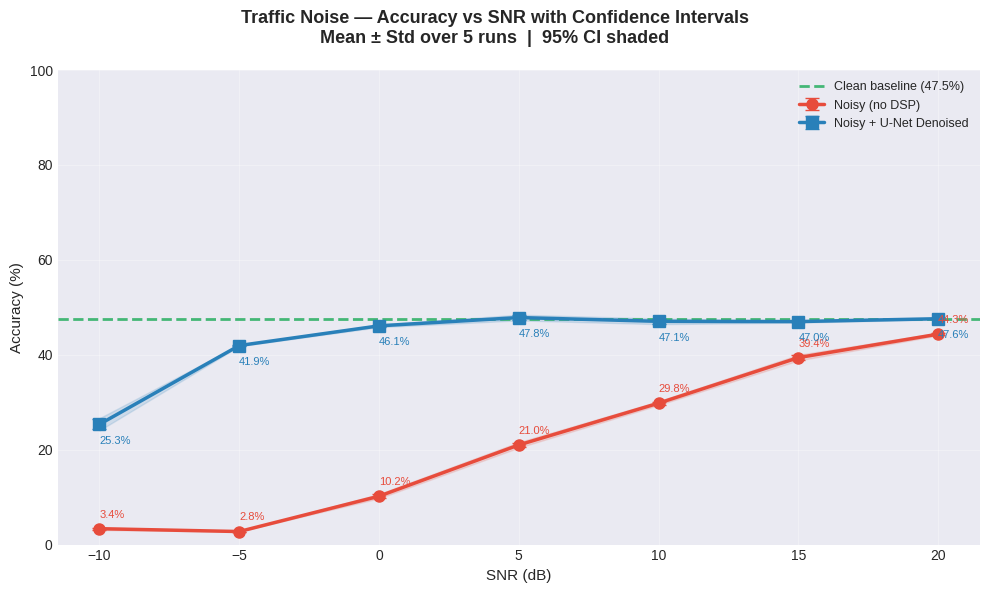

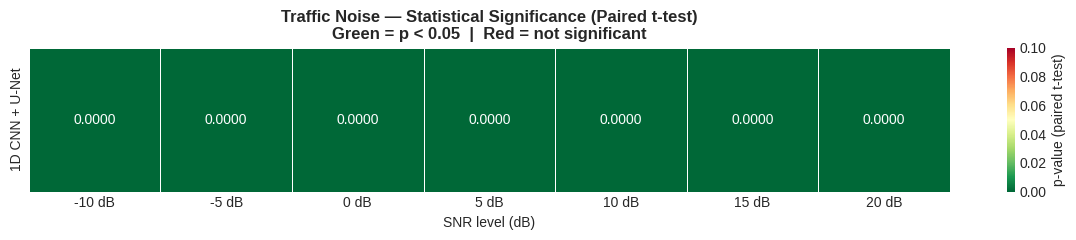


Per-run detail:
 SNR_dB  Run  Seed  Noisy_%  UNet_%
    -10    1    42     3.50   24.75
    -10    2    43     3.50   24.00
    -10    3    44     3.25   25.25
    -10    4    45     3.00   26.50
    -10    5    46     3.50   26.25
     -5    1    42     2.75   41.75
     -5    2    43     2.75   42.00
     -5    3    44     2.75   42.00
     -5    4    45     2.75   42.00
     -5    5    46     2.75   42.00
      0    1    42    10.25   46.00
      0    2    43    10.75   45.75
      0    3    44    10.25   46.25
      0    4    45     9.75   46.25
      0    5    46    10.00   46.25
      5    1    42    21.50   48.00
      5    2    43    20.50   47.25
      5    3    44    21.25   47.50
      5    4    45    21.25   48.50
      5    5    46    20.50   48.00
     10    1    42    29.50   47.75
     10    2    43    30.25   46.50
     10    3    44    30.00   47.25
     10    4    45    29.75   47.00
     10    5    46    29.50   46.75
     15    1    42    39.25   47.25
     15    

In [18]:
# @title Cell 18 · Traffic statistical detail

stat_rows = []
stat_rows.append({
    "SNR_dB"      : "Clean",
    "Condition"   : "Clean Baseline",
    "Mean_Acc_%"  : round(baseline_acc * 100, 2),
    "Std_%"       : 0.0,
    "CI95_half_%" : 0.0,
    "Recovery_%"  : "—",
    "p_value"     : "—",
    "Significant" : "—",
})

for snr in TRAFFIC_SNR_LEVELS:
    na = np.array(results["_traffic_runs_noisy"][snr])
    da = np.array(results["_traffic_runs_denoised"][snr])

    if N_RUNS >= 2 and not np.allclose(na, da):
        _, p_val = ttest_rel(da, na)
        sig      = "Yes ✓" if p_val < 0.05 else "No"
    else:
        p_val, sig = float("nan"), "—"

    recovery = float(np.mean(da) - np.mean(na)) * 100

    for cond, arr in [("Noisy (no DSP)", na), ("Noisy + U-Net", da)]:
        stat_rows.append({
            "SNR_dB"      : snr,
            "Condition"   : cond,
            "Mean_Acc_%"  : round(np.mean(arr) * 100, 2),
            "Std_%"       : round(np.std(arr, ddof=1) * 100, 2) if N_RUNS > 1 else 0.0,
            "CI95_half_%" : round(ci95(arr) * 100, 2),
            "Recovery_%"  : round(recovery, 2) if "U-Net" in cond else "—",
            "p_value"     : round(p_val, 4) if not np.isnan(p_val) else "—",
            "Significant" : sig if "U-Net" in cond else "—",
        })

df_traffic_stats = pd.DataFrame(stat_rows)
traffic_csv = RESULTS_DIR / "traffic_unet_statistics.csv"
df_traffic_stats.to_csv(str(traffic_csv), index=False)

print("\n" + "=" * 95)
print("  TRAFFIC NOISE — STATISTICAL DETAIL  |  1D CNN + U-Net Denoiser")
print(f"  Runs: {N_RUNS}  |  Seeds: {SEEDS}  |  SNR levels: {TRAFFIC_SNR_LEVELS} dB")
print("=" * 95)
print(df_traffic_stats.to_string(index=False))
print("=" * 95)
print("  ✓ = paired t-test p < 0.05")
print(f"\n  Saved → {traffic_csv}")

TR_COLORS = {"noisy": "#e74c3c", "denoised": "#2980b9", "clean": "#27ae60"}
snrs   = TRAFFIC_SNR_LEVELS
n_mean = [np.mean(results["_traffic_runs_noisy"][s])    * 100 for s in snrs]
n_std  = [np.std( results["_traffic_runs_noisy"][s],  ddof=1) * 100 for s in snrs]
d_mean = [np.mean(results["_traffic_runs_denoised"][s]) * 100 for s in snrs]
d_std  = [np.std( results["_traffic_runs_denoised"][s], ddof=1) * 100 for s in snrs]
n_ci   = [ci95(np.array(results["_traffic_runs_noisy"][s]))    * 100 for s in snrs]
d_ci   = [ci95(np.array(results["_traffic_runs_denoised"][s])) * 100 for s in snrs]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    f"Traffic Noise — Accuracy vs SNR with Confidence Intervals\n"
    f"Mean ± Std over {N_RUNS} runs  |  95% CI shaded",
    fontsize=13, fontweight="bold")
ax.axhline(baseline_acc * 100, color=TR_COLORS["clean"], lw=2, ls="--",
           label=f"Clean baseline ({baseline_acc*100:.1f}%)", alpha=0.85)
ax.fill_between(snrs, np.array(n_mean)-np.array(n_ci),
                np.array(n_mean)+np.array(n_ci), alpha=0.15, color=TR_COLORS["noisy"])
ax.fill_between(snrs, np.array(d_mean)-np.array(d_ci),
                np.array(d_mean)+np.array(d_ci), alpha=0.15, color=TR_COLORS["denoised"])
ax.errorbar(snrs, n_mean, yerr=n_std, fmt="o-", color=TR_COLORS["noisy"],
            capsize=5, lw=2.5, ms=8, label="Noisy (no DSP)")
ax.errorbar(snrs, d_mean, yerr=d_std, fmt="s-", color=TR_COLORS["denoised"],
            capsize=5, lw=2.5, ms=8, label="Noisy + U-Net Denoised")
for s, nm, dm in zip(snrs, n_mean, d_mean):
    ax.annotate(f"{nm:.1f}%", (s, nm), textcoords="offset points",
                xytext=(0, 8),  fontsize=8, color=TR_COLORS["noisy"])
    ax.annotate(f"{dm:.1f}%", (s, dm), textcoords="offset points",
                xytext=(0,-14), fontsize=8, color=TR_COLORS["denoised"])
ax.set_xlabel("SNR (dB)", fontsize=11); ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_xticks(snrs); ax.set_ylim(0, 100)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "traffic_unet_accuracy_ci.png"), dpi=150, bbox_inches="tight")
plt.show()

# p-value heatmap
p_vals = []
for snr in TRAFFIC_SNR_LEVELS:
    na = np.array(results["_traffic_runs_noisy"][snr])
    da = np.array(results["_traffic_runs_denoised"][snr])
    if N_RUNS >= 2 and not np.allclose(na, da):
        _, pv = ttest_rel(da, na)
    else:
        pv = float("nan")
    p_vals.append(pv)

p_matrix = np.array([p_vals])
fig, ax  = plt.subplots(figsize=(12, 2.5))
sns.heatmap(p_matrix, annot=True, fmt=".4f",
            cmap="RdYlGn_r", vmin=0, vmax=0.1,
            xticklabels=[f"{s} dB" for s in TRAFFIC_SNR_LEVELS],
            yticklabels=["1D CNN + U-Net"],
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "p-value (paired t-test)"})
ax.set_title("Traffic Noise — Statistical Significance (Paired t-test)\n"
             "Green = p < 0.05  |  Red = not significant",
             fontsize=12, fontweight="bold")
ax.set_xlabel("SNR level (dB)")
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "traffic_unet_pvalue_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-run detail
run_rows = []
for snr in TRAFFIC_SNR_LEVELS:
    for run_idx, run_seed in enumerate(SEEDS):
        run_rows.append({
            "SNR_dB"  : snr,
            "Run"     : run_idx + 1,
            "Seed"    : run_seed,
            "Noisy_%" : round(results["_traffic_runs_noisy"][snr][run_idx]    * 100, 2),
            "UNet_%"  : round(results["_traffic_runs_denoised"][snr][run_idx] * 100, 2),
        })
df_runs  = pd.DataFrame(run_rows)
runs_csv = RESULTS_DIR / "traffic_unet_per_run.csv"
df_runs.to_csv(str(runs_csv), index=False)
print("\nPer-run detail:")
print(df_runs.to_string(index=False))
print(f"\n  Saved → {runs_csv.name}")

In [19]:
# @title Cell 19 · Grand final summary

print("\n" + "═" * 80)
print("  GRAND FINAL SUMMARY — All Noise Types  |  1D CNN v2  |  U-Net Denoiser")
print("═" * 80)
print(f"  Clean baseline: {baseline_acc*100:.2f}%\n")

print("  ── Synthetic Noise (U-Net) ──────────────────────────────────────────────")
for noise_label, (nkey, dkey, snr_list) in {
        k: v for k, v in NOISE_CONFIGS.items() if k != "Traffic Noise"}.items():
    print(f"\n  {noise_label}:")
    for snr in snr_list:
        print(f"    {snr:>4}dB | Noisy: {results[nkey][snr]*100:.1f}%"
              f"  → U-Net: {results[dkey][snr]*100:.1f}%"
              f"  | SNR gain: {results['snr_gain'][(nkey,snr)]:+.2f}dB")

print(f"\n  ── Real Traffic Noise (U-Net | {N_RUNS} runs, paired t-test) ──────────────────")
print(f"  {'SNR':>6}  {'Noisy':>9}  {'±std':>6}  "
      f"{'U-Net':>9}  {'±std':>6}  {'Recovery':>10}  {'p-value':>9}")
print("  " + "─" * 65)
for snr in TRAFFIC_SNR_LEVELS:
    na  = np.array(results["_traffic_runs_noisy"][snr])
    da  = np.array(results["_traffic_runs_denoised"][snr])
    rec = (np.mean(da) - np.mean(na)) * 100
    if N_RUNS >= 2 and not np.allclose(na, da):
        _, pv = ttest_rel(da, na)
        sig = " ✓" if pv < 0.05 else "  "
    else:
        pv, sig = float("nan"), "  "
    print(f"  {snr:>4} dB  "
          f"{np.mean(na)*100:>7.2f}%  "
          f"{np.std(na, ddof=1)*100:>5.2f}%  "
          f"{np.mean(da)*100:>7.2f}%  "
          f"{np.std(da, ddof=1)*100:>5.2f}%  "
          f"{rec:>+9.2f}%  "
          f"{pv:>9.4f}{sig}")
print("  ✓ = statistically significant (p < 0.05)")
print(f"\n  All outputs saved to: {RESULTS_DIR}")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
  GRAND FINAL SUMMARY — All Noise Types  |  1D CNN v2  |  U-Net Denoiser
════════════════════════════════════════════════════════════════════════════════
  Clean baseline: 47.50%

  ── Synthetic Noise (U-Net) ──────────────────────────────────────────────

  White Noise:
      20dB | Noisy: 37.0%  → U-Net: 47.2%  | SNR gain: +2.28dB
      15dB | Noisy: 33.1%  → U-Net: 47.2%  | SNR gain: +3.84dB
      10dB | Noisy: 23.0%  → U-Net: 46.6%  | SNR gain: +5.43dB
       5dB | Noisy: 16.4%  → U-Net: 45.6%  | SNR gain: +7.03dB
       0dB | Noisy: 10.2%  → U-Net: 33.3%  | SNR gain: +8.12dB

  Gaussian Noise:
      20dB | Noisy: 37.0%  → U-Net: 47.3%  | SNR gain: +2.27dB
      15dB | Noisy: 33.1%  → U-Net: 47.0%  | SNR gain: +3.83dB
      10dB | Noisy: 23.2%  → U-Net: 46.5%  | SNR gain: +5.40dB
       5dB | Noisy: 16.4%  → U-Net: 45.2%  | SNR gain: +6.98dB
       0dB | Noisy: 10.5%  → U-Net: 32.4%  | SNR gain: +8.01

Clean Baseline Accuracy: 47.50%
                  precision    recall  f1-score   support

        airplane       0.17      0.12      0.14         8
       breathing       0.29      0.25      0.27         8
  brushing_teeth       0.58      0.88      0.70         8
     can_opening       0.83      0.62      0.71         8
        car_horn       0.70      0.88      0.78         8
             cat       0.50      0.50      0.50         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.55      0.75      0.63         8
    church_bells       0.54      0.88      0.67         8
        clapping       0.60      0.38      0.46         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       0.83      0.62      0.71         8
             cow       0.67      0.25      0.36         8
  crackling_fire       0.14      0.12      0.13         8
        crickets       0.36      0.62  

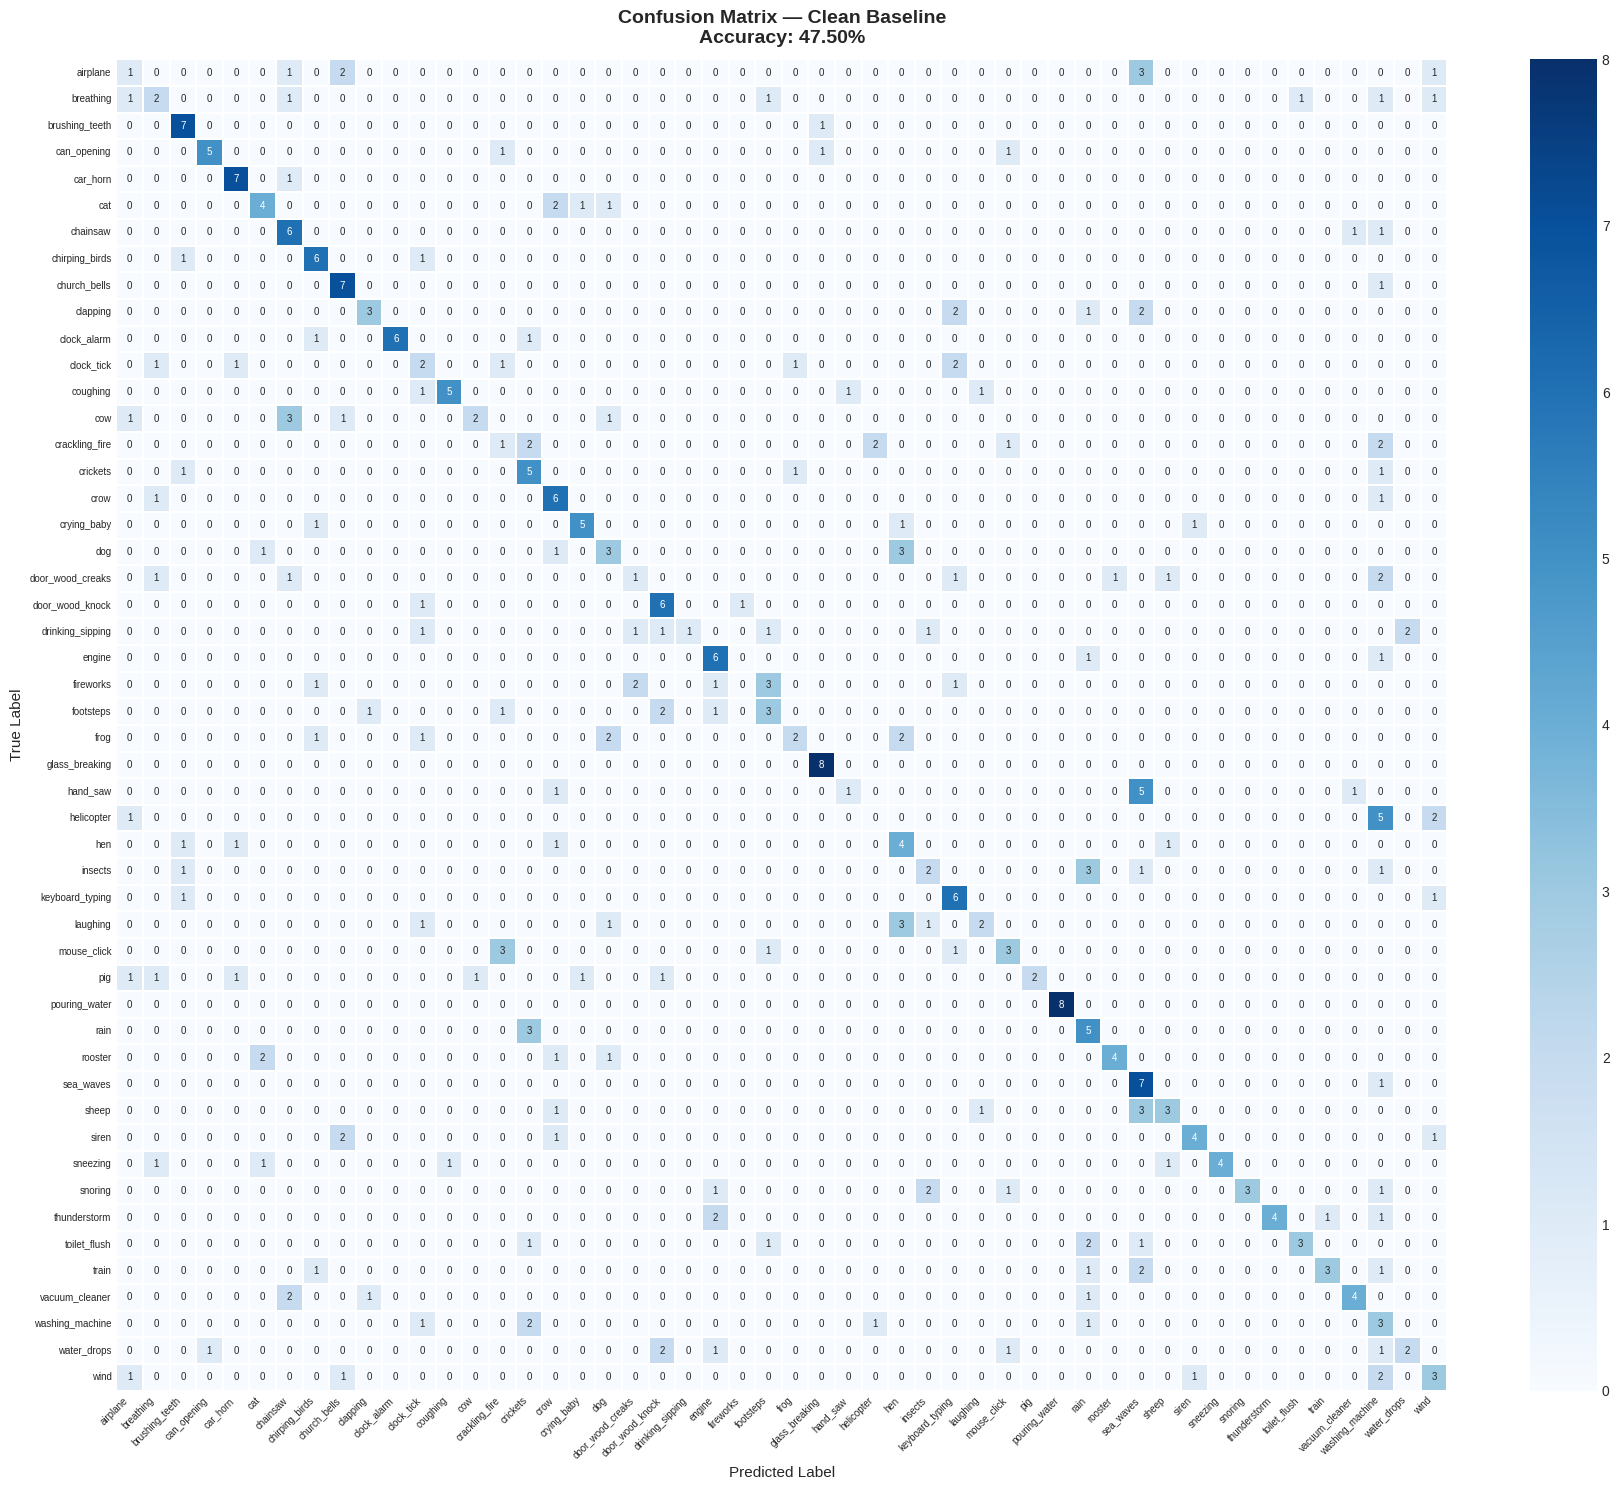

✅  Saved → cm_1_clean_baseline.png
Traffic Noise (-5 dB) — Accuracy (seed=42): 2.75%
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.00      0.00      0.00         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.02      1.00      0.04         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.27      0.38      0.32         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0.00      0.00      0.00         8
  crackling_fire       0.00      0.00      0

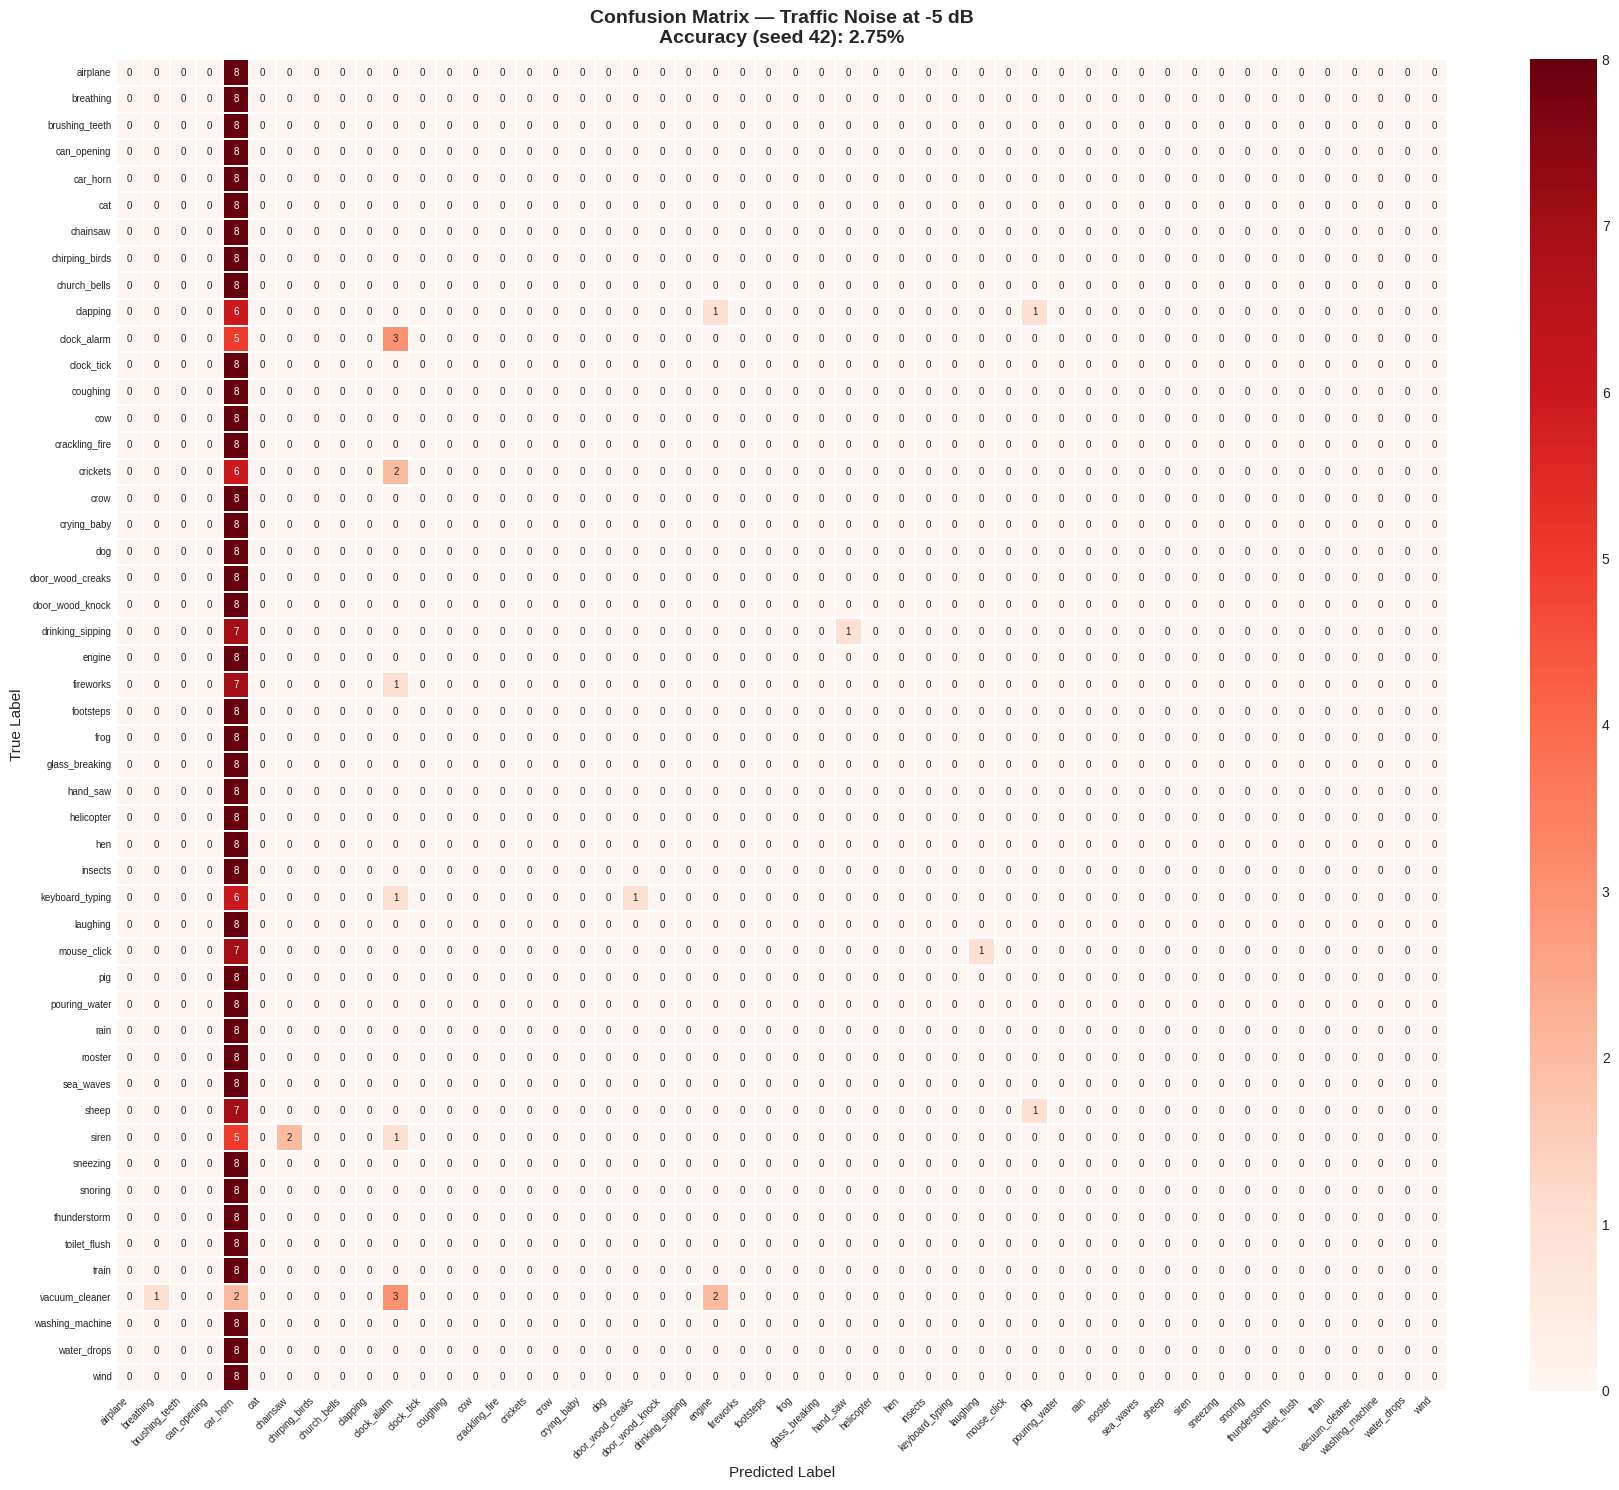

✅  Saved → cm_2_traffic_noisy_-5dB.png
U-Net Denoised (-5 dB) — Accuracy (seed=42): 41.75%
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.15      0.38      0.21         8
  brushing_teeth       0.86      0.75      0.80         8
     can_opening       0.88      0.88      0.88         8
        car_horn       0.46      0.75      0.57         8
             cat       0.36      0.50      0.42         8
        chainsaw       0.30      0.88      0.45         8
  chirping_birds       0.37      0.88      0.52         8
    church_bells       0.44      0.50      0.47         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       0.80      0.50      0.62         8
             cow       0.50      0.38      0.43         8
  crackling_fire       0.12      0.25 

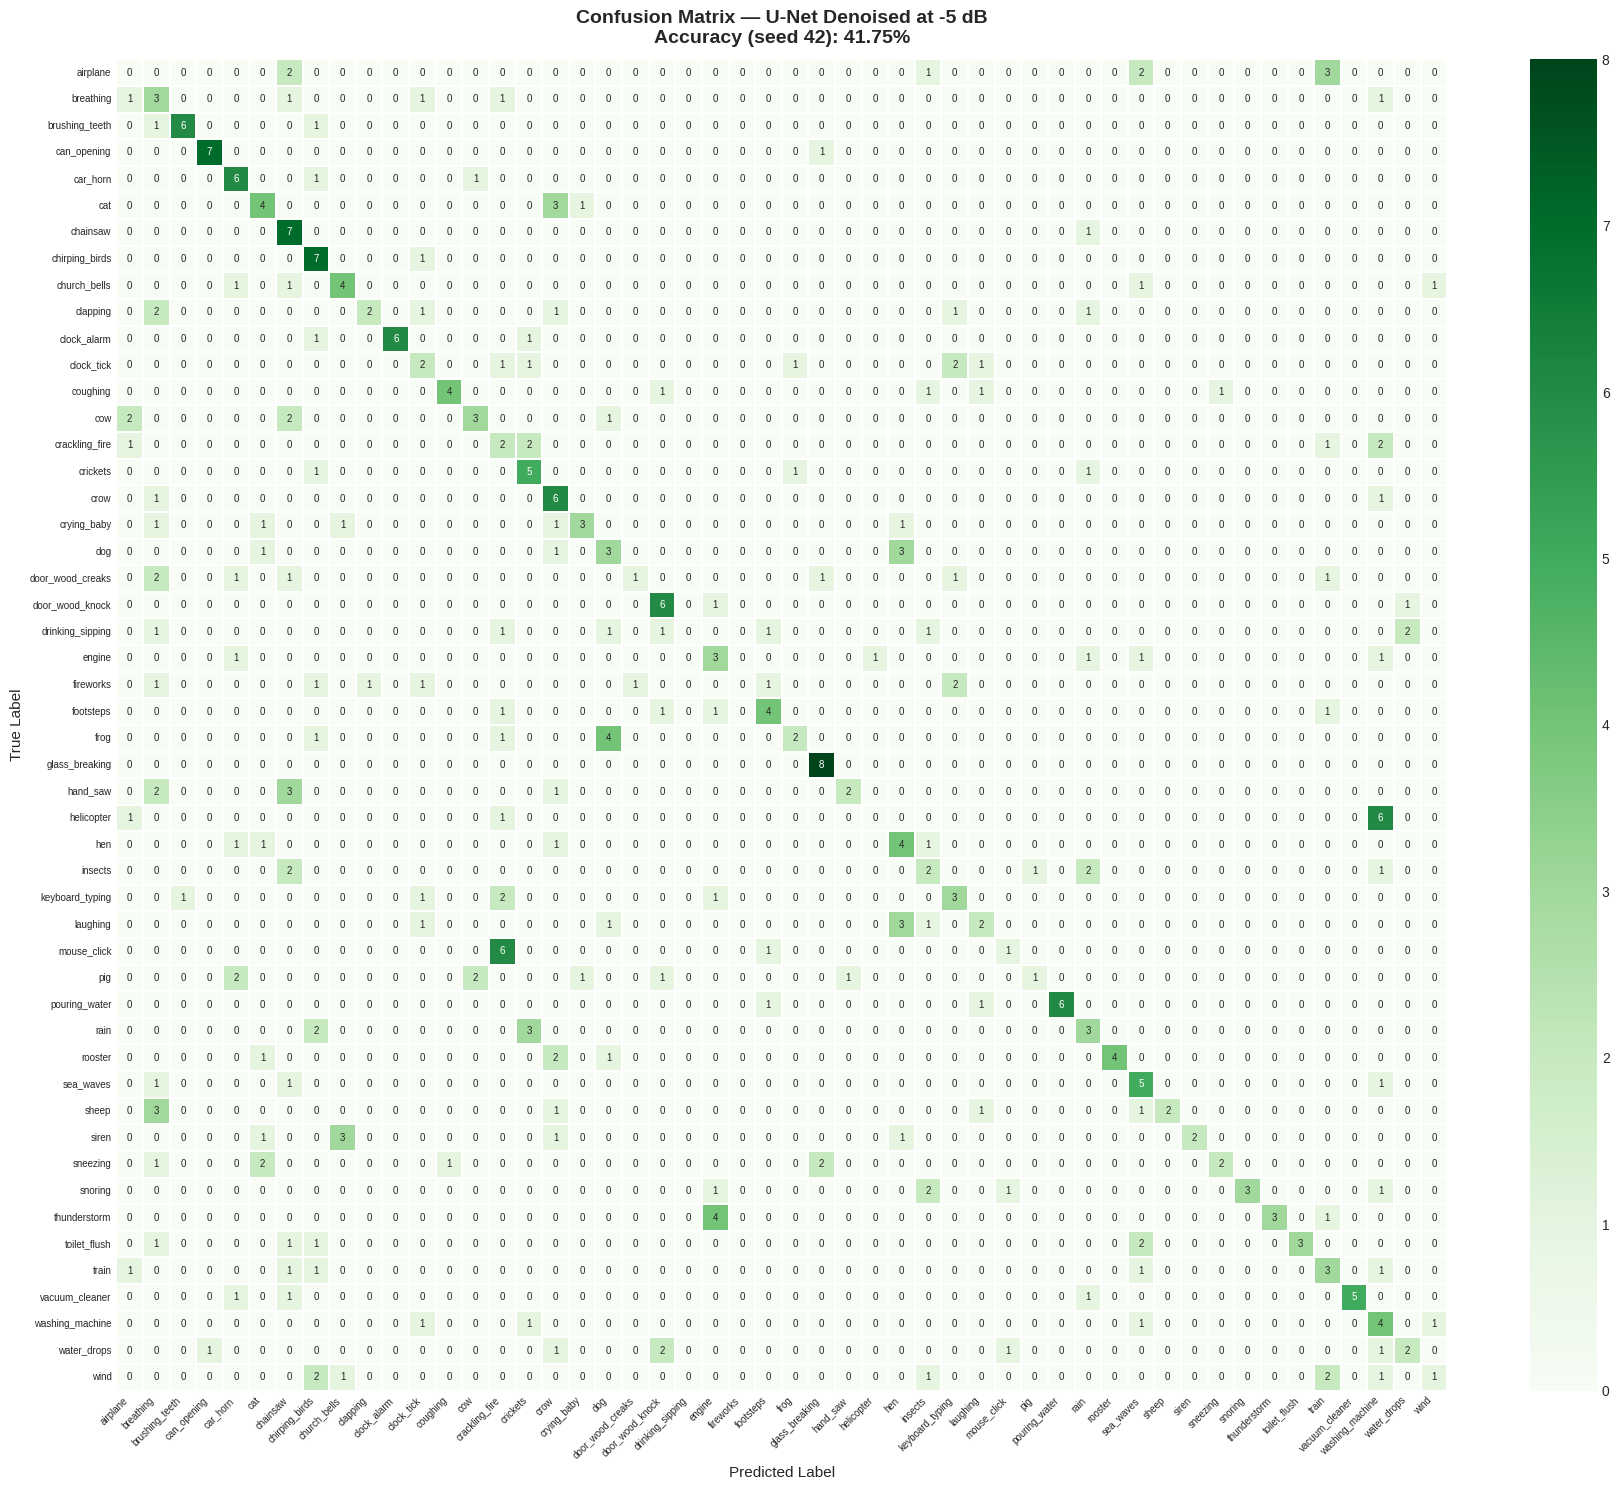

✅  Saved → cm_3_unet_denoised_-5dB.png

  CONFUSION MATRIX SUMMARY
  Clean Baseline             : 47.50%
  Traffic Noisy (-5 dB)      : 2.75%  (seed 42 shown in CM)  |  mean ± std (N=5): 2.75% ± 0.00%
  U-Net Denoised (-5 dB)     : 41.75%  (seed 42 shown in CM)  |  mean ± std (N=5): 41.95% ± 0.11%
  Recovery (single-run CM)   : +39.00%
  Recovery (mean across runs): +39.20%
  ── For your report ──
  Traffic noisy at -5 dB:    2.75% ± 0.00%
  U-Net denoised at -5 dB:   41.95% ± 0.11%


In [20]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL CM-1 · Confusion Matrix 1 — Clean Baseline
#             For: 1D_CNN_UNet_Correct.ipynb
#             Insert AFTER Cell 15 (evaluate() helper + clean baseline) —
#             or anywhere after, since CM-1 just re-predicts on X_test.
#             dsp_pipeline() in this notebook is the REAL PyTorch U-Net
#             (STFT-based spectral mask denoiser, defined in Cells 8-14).
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell CM-1 · Confusion Matrix — Clean Baseline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

preds_clean   = np.argmax(final_model.predict(X_test, verbose=0), axis=1)
acc_clean_cm  = float(np.mean(preds_clean == y_test))

print(f"Clean Baseline Accuracy: {acc_clean_cm*100:.2f}%")
print(classification_report(y_test, preds_clean, target_names=le.classes_, zero_division=0))

cm_clean = confusion_matrix(y_test, preds_clean)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_clean, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=0.3, annot_kws={"size": 7},
)
ax.set_title(
    f"Confusion Matrix — Clean Baseline\nAccuracy: {acc_clean_cm*100:.2f}%",
    fontsize=14, fontweight="bold", pad=12,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "cm_1_clean_baseline.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅  Saved → cm_1_clean_baseline.png")


# ════════════════════════════════════════════════════════════════════════════════
# CELL CM-2 · Confusion Matrix 2 — Traffic Noise at -5 dB
#             Uses a single representative run (seed 42) so the displayed
#             accuracy matches the same statistic reported in the stats table
#             (mean accuracy across runs from Cell 18), not a majority-vote
#             ensemble metric.
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell CM-2 · Confusion Matrix — Traffic Noise at -5 dB (single representative run)

TARGET_SNR = -5   # change this if you want a different SNR level

# --- Use the first seed (42) as the representative run ---
# This keeps the confusion matrix consistent with the "mean accuracy" reported
# in the stats table — each run individually sits close to the mean (2.75% ± 0.00%
# for noisy at -5dB), so seed 42 alone is representative of the primary metric.
REP_SEED = SEEDS[0]

X_noisy_cm    = add_traffic_noise_batch(X_test, TARGET_SNR, REP_SEED)
preds_noisy   = np.argmax(final_model.predict(X_noisy_cm, verbose=0), axis=1)
acc_noisy_cm  = float(np.mean(preds_noisy == y_test))

print(f"Traffic Noise ({TARGET_SNR} dB) — Accuracy (seed={REP_SEED}): {acc_noisy_cm*100:.2f}%")
print(classification_report(y_test, preds_noisy, target_names=le.classes_, zero_division=0))

cm_noisy = confusion_matrix(y_test, preds_noisy)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_noisy, annot=True, fmt="d", cmap="Reds",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=0.3, annot_kws={"size": 7},
)
ax.set_title(
    f"Confusion Matrix — Traffic Noise at {TARGET_SNR} dB\n"
    f"Accuracy (seed {REP_SEED}): {acc_noisy_cm*100:.2f}%",
    fontsize=14, fontweight="bold", pad=12,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / f"cm_2_traffic_noisy_{TARGET_SNR}dB.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved → cm_2_traffic_noisy_{TARGET_SNR}dB.png")


# ════════════════════════════════════════════════════════════════════════════════
# CELL CM-3 · Confusion Matrix 3 — U-Net Denoised at -5 dB
#             Same representative seed (42) as CM-2 — keeps the comparison
#             apples-to-apples and aligned with the mean-accuracy stats table.
#             dsp_pipeline() here is the trained PyTorch U-Net (Cells 8-14).
# ════════════════════════════════════════════════════════════════════════════════
# @title Cell CM-3 · Confusion Matrix — U-Net Denoised at -5 dB (single representative run + mean±std)

X_noisy_dn      = add_traffic_noise_batch(X_test, TARGET_SNR, REP_SEED)
X_denoised_cm   = dsp_pipeline(X_noisy_dn)
preds_denoised  = np.argmax(final_model.predict(X_denoised_cm, verbose=0), axis=1)
acc_denoised_cm = float(np.mean(preds_denoised == y_test))

print(f"U-Net Denoised ({TARGET_SNR} dB) — Accuracy (seed={REP_SEED}): {acc_denoised_cm*100:.2f}%")
print(classification_report(y_test, preds_denoised, target_names=le.classes_, zero_division=0))

cm_denoised = confusion_matrix(y_test, preds_denoised)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_denoised, annot=True, fmt="d", cmap="Greens",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=0.3, annot_kws={"size": 7},
)
ax.set_title(
    f"Confusion Matrix — U-Net Denoised at {TARGET_SNR} dB\n"
    f"Accuracy (seed {REP_SEED}): {acc_denoised_cm*100:.2f}%",
    fontsize=14, fontweight="bold", pad=12,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / f"cm_3_unet_denoised_{TARGET_SNR}dB.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved → cm_3_unet_denoised_{TARGET_SNR}dB.png")

# --- Summary (with mean ± std across all 5 runs, matching the stats table) ---
# Recompute the full 5-run distributions so we can report mean ± std alongside
# the single-seed confusion matrix accuracy shown above.

run_accs_noisy, run_accs_denoised = [], []
for s in SEEDS:
    Xn = add_traffic_noise_batch(X_test, TARGET_SNR, s)
    run_accs_noisy.append(float(np.mean(np.argmax(final_model.predict(Xn, verbose=0), axis=1) == y_test)))
    Xd = dsp_pipeline(Xn)
    run_accs_denoised.append(float(np.mean(np.argmax(final_model.predict(Xd, verbose=0), axis=1) == y_test)))

run_accs_noisy    = np.array(run_accs_noisy)
run_accs_denoised = np.array(run_accs_denoised)

mean_noisy,    std_noisy    = run_accs_noisy.mean()    * 100, run_accs_noisy.std(ddof=1)    * 100
mean_denoised, std_denoised = run_accs_denoised.mean() * 100, run_accs_denoised.std(ddof=1) * 100
recovery_mean = mean_denoised - mean_noisy

print("\n" + "="*55)
print("  CONFUSION MATRIX SUMMARY")
print("="*55)
print(f"  Clean Baseline             : {acc_clean_cm*100:.2f}%")
print(f"  Traffic Noisy ({TARGET_SNR} dB)      : {acc_noisy_cm*100:.2f}%  "
      f"(seed {REP_SEED} shown in CM)  |  mean ± std (N={N_RUNS}): {mean_noisy:.2f}% ± {std_noisy:.2f}%")
print(f"  U-Net Denoised ({TARGET_SNR} dB)     : {acc_denoised_cm*100:.2f}%  "
      f"(seed {REP_SEED} shown in CM)  |  mean ± std (N={N_RUNS}): {mean_denoised:.2f}% ± {std_denoised:.2f}%")
print(f"  Recovery (single-run CM)   : {(acc_denoised_cm - acc_noisy_cm)*100:+.2f}%")
print(f"  Recovery (mean across runs): {recovery_mean:+.2f}%")
print("="*55)
print(f"  ── For your report ──")
print(f"  Traffic noisy at {TARGET_SNR} dB:    {mean_noisy:.2f}% ± {std_noisy:.2f}%")
print(f"  U-Net denoised at {TARGET_SNR} dB:   {mean_denoised:.2f}% ± {std_denoised:.2f}%")